##### <p style="text-align: center;"> ![alt text](./utilities/cilss.png)</p>
# <p style="text-align: center;">AGHRYMET RCC-WAS</p>
#### &copy; Mandela HOUNGNIBO 2024 (Find more [here](https://github.com/hmandela))

## Library

In [1]:
from wass2s import *
import importlib
from pathlib import Path
import warnings
import gc
warnings.filterwarnings("ignore")

#### Set forecast working directory

In [2]:
# Set forecast working directory
dir_s2s = "./Agro_PRESASS_2025"

In [3]:
dir_s2s = Path(dir_s2s)
os.makedirs(dir_s2s, exist_ok=True)
### Save consolidated results
hdcst_consolidated = {}
fcst_consolidated = {}
scores_consolidated = {}
### Save score
dir_save_score = f"{dir_s2s}/scores"
os.makedirs(dir_save_score, exist_ok=True)
### Save forecasts
dir_to_forecast = f"{dir_s2s}/forecasts"
os.makedirs(dir_to_forecast, exist_ok=True)

#### Set Climatological Years

In [4]:
# Set Climatological Years
clim_year_start = 1994 #1991
clim_year_end = 2016 #2020
dist_method = "t" # "gamma", "t", "lognormal", "normal", "nonparam"
fcst_labels = ["Early", "Near-Normal", "Late"]

## Download Observation and Process 


#### Load Downloader 

In [5]:
# Load WAS_S2S downloader class
downloader = WAS_Download()

In [6]:
# Filter observation names to identify precipitation-related models
variables_obs = [key for key in downloader.AgroObsName().keys() if "PRCP" in key]

# Specify the directory to save downloaded model data
dir_to_save_Obs = f"{dir_s2s}/Observation"

# Define the observation period (years 1993 to 2016)
year_start = 1991
year_end = 2024

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent_obs = [21, -18, 7, 25]   # [Northern, Western, Southern and Eastern] 

# Specify whether to overwrite existing files when downloading data
force_download = False

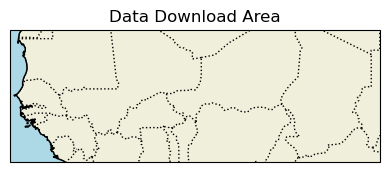

In [7]:
plot_map([extent_obs[1],extent_obs[3],extent_obs[2],extent_obs[0]], title="Data Download Area", fig_size=(4,3))

In [8]:
downloader.WAS_Download_AgroIndicators_daily(dir_to_save_Obs, variables_obs, year_start, year_end, extent_obs, force_download=force_download)
downloader.WAS_Download_AgroIndicators_daily(dir_to_save_Obs, variables_obs, datetime.datetime.now().year, datetime.datetime.now().year, extent_obs, force_download=force_download)

Agro_PRESASS_2025/Observation/Daily_PRCP_1991_2024.nc already exists. Skipping download.
Agro_PRESASS_2025/Observation/Daily_PRCP_2025_2025.nc already exists. Skipping download.


In [9]:
#### Process predictant
rainfall = prepare_predictand(dir_to_save_Obs, variables_obs, year_start, year_end, daily=True, ds=False)
rainfall_for_forecast_year = prepare_predictand(dir_to_save_Obs, variables_obs, datetime.datetime.now().year, datetime.datetime.now().year, daily=True, ds=False)
season_str = agrometparam = "Cessation"
season_obs = [datetime.datetime.now().month+1]

## Compute cessation

In [10]:
### Choose number of cores according your computer
nb_cores=4

In [11]:
## cessation criteria
user_criteria = cessation_criteria
user_criteria

{1: {'zone_name': 'Sahel200_100mm',
  'date_dry_soil': '01-01',
  'start_search': '09-01',
  'ETP': 5.0,
  'Cap_ret_maxi': 70,
  'end_search': '10-05'},
 2: {'zone_name': 'Sahel400_200mm',
  'date_dry_soil': '01-01',
  'start_search': '09-01',
  'ETP': 5.0,
  'Cap_ret_maxi': 70,
  'end_search': '11-10'},
 3: {'zone_name': 'Sahel600_400mm',
  'date_dry_soil': '01-01',
  'start_search': '09-15',
  'ETP': 5.0,
  'Cap_ret_maxi': 70,
  'end_search': '11-15'},
 4: {'zone_name': 'Soudan',
  'date_dry_soil': '01-01',
  'start_search': '10-01',
  'ETP': 4.5,
  'Cap_ret_maxi': 70,
  'end_search': '11-30'},
 5: {'zone_name': 'Golfe_Of_Guinea',
  'date_dry_soil': '01-01',
  'start_search': '10-15',
  'ETP': 4.0,
  'Cap_ret_maxi': 70,
  'end_search': '12-01'}}

In [12]:
user_criteria[4]["thrd_rain_day"] = 0.85
user_criteria[5]["thrd_rain_day"] = 0.85

##### Compute cessation for gridded products

In [13]:
# load cessation class
was_cessation = WAS_compute_cessation(user_criteria)
cessation = was_cessation.compute(daily_data=rainfall, nb_cores=nb_cores)

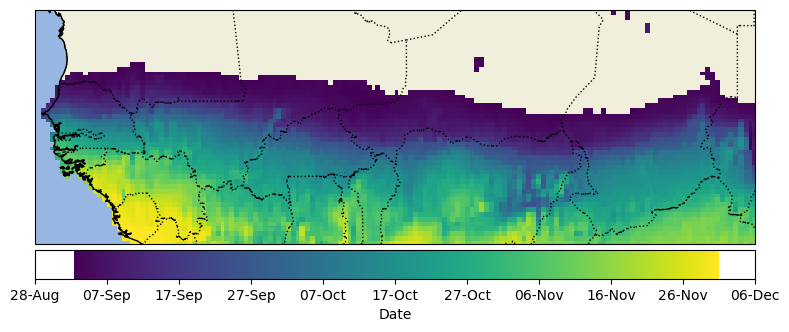

In [14]:
plot_date(cessation.mean(dim='T'))

#### Process cessation in combining with Ground-Observation

In [15]:
# ## Path to the CPT file
# cpt_input_file_path = "./Observation/MAM_1991-2023_.txt"

In [16]:
## Read CSV
# df = pd.read_csv(cpt_input_file_path, na_values=-999.0, sep='\t')
# cessation_df = df[(df['STATION'] == 'LAT') | (df['STATION'] == 'LON') | 
#                  (pd.to_numeric(df['STATION'], errors='coerce').between(year_start, year_end))]

In [17]:
## Instantiate WAS_Merging class
# data_merger = WAS_Merging(cessation_df, cessation, date_month_day= '02-01')
# cessation__, _ = data_merger.simple_bias_adjustment(do_cross_validation=False)

In [18]:
# data_merger.plot_merging_comparaison(cessation_df, cessation , cessation__)

In [19]:
# cessation = cessation__

# 1st - Approach: Choice of Best Dynamical models and weighted Average

In [20]:
# Filter model names to identify precipitation-related models
center_variable = ['ECMWF_51.PRCP', 'METEOFRANCE_8.PRCP',
                   #'UKMO_603.PRCP', # Comment this line if your initialization month starts with March
                   'UKMO_604.PRCP',  # Comment this line if your initialization month starts before April
                   # 'DWD_21.PRCP', # Comment this line if your initialization month starts with March
                   'DWD_22.PRCP', # Comment this line if your initialization month starts before March
                   'CMCC_35.PRCP', 'ECCC_4.PRCP', 'ECCC_5.PRCP', 'JMA_3.PRCP', 'NCEP_2.PRCP'] 


# Specify the directory to save downloaded model data
dir_to_save_model = f"{dir_s2s}/daily_model_data"

# Define the month for model initialization (June)
month_of_initialization = "04"
day_of_initialization ="01"

# Define lead times corresponding to seasonal forecast targets
leadtime_hour = [str(i) for i in range(24, 5161, 24)] 

# Define the hindcast period for model data (years 1993 to 2016)
year_start_model = 1993
year_end_model = 2016

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent_obs = [21, -18, 7, 25]  # [Northern, Western, Southern and Eastern] 

# Define if you want to download forecast or hindcast
forecast = None
ensemble_mean = 'mean',
# Specify whether to overwrite existing files when downloading data
force_download = False

In [21]:
file_path_hdcst = downloader.WAS_Download_Models_Daily(dir_to_save_model,center_variable,month_of_initialization, day_of_initialization, leadtime_hour, year_start_model, year_end_model, extent_obs, forecast, ensemble_mean, force_download,)

Agro_PRESASS_2025/daily_model_data/hindcast_ecmwf51_PRCP_Apr01_1993_2016_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/hindcast_meteo_france8_PRCP_Apr01_1993_2016_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/hindcast_ukmo604_PRCP_Apr01_1993_2016_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/hindcast_dwd22_PRCP_Apr01_1993_2016_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/hindcast_cmcc35_PRCP_Apr01_1993_2016_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/hindcast_eccc4_PRCP_Apr01_1993_2016_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/hindcast_eccc5_PRCP_Apr01_1993_2016_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/hindcast_jma3_PRCP_Apr01_1993_2016_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/hindcast_ncep2_PR

In [22]:
forecast = 2025

In [23]:
file_path_fcst = downloader.WAS_Download_Models_Daily(dir_to_save_model,center_variable,month_of_initialization, day_of_initialization, leadtime_hour, year_start_model, year_end_model, extent_obs, forecast, ensemble_mean, force_download,)

Agro_PRESASS_2025/daily_model_data/forecast_ecmwf51_PRCP_Apr01_2025_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/forecast_meteo_france8_PRCP_Apr01_2025_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/forecast_ukmo604_PRCP_Apr01_2025_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/forecast_dwd22_PRCP_Apr01_2025_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/forecast_cmcc35_PRCP_Apr01_2025_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/forecast_eccc4_PRCP_Apr01_2025_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/forecast_eccc5_PRCP_Apr01_2025_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/forecast_jma3_PRCP_Apr01_2025_24-5160.nc already exists. Skipping download.
Agro_PRESASS_2025/daily_model_data/forecast_ncep2_PRCP_Apr01_2025_24-5160.nc already exists.

In [24]:
hindcast_files, forecast_files = process_model_for_other_params(was_cessation, dir_s2s, file_path_hdcst, file_path_fcst, rainfall, 
rainfall_for_forecast_year, month_of_initialization, year_start_model, year_end_model, forecast, nb_cores=4, agrometparam=agrometparam)

[SKIP] Agro_PRESASS_2025/model_data/hindcast_ecmwf51_Cessation_AprIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/hindcast_meteo_france8_Cessation_AprIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/hindcast_ukmo604_Cessation_AprIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/hindcast_dwd22_Cessation_AprIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/hindcast_cmcc35_Cessation_AprIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/hindcast_eccc4_Cessation_AprIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/hindcast_eccc5_Cessation_AprIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/hindcast_jma3_Cessation_AprIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/hindcast_ncep2_Cessation_AprIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/forecast_ecmwf51_Cessation_AprIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_data/forecast_meteo_france8_Cessation_AprIc.nc already exists.
[SKIP] Agro_PRESASS_2025/model_d

In [25]:
was_verify = WAS_Verification(dist_method=dist_method)

#### Validation of GCM

In [26]:
score = ["Pearson", "MAE", "GROC"]

Pearson Correlation


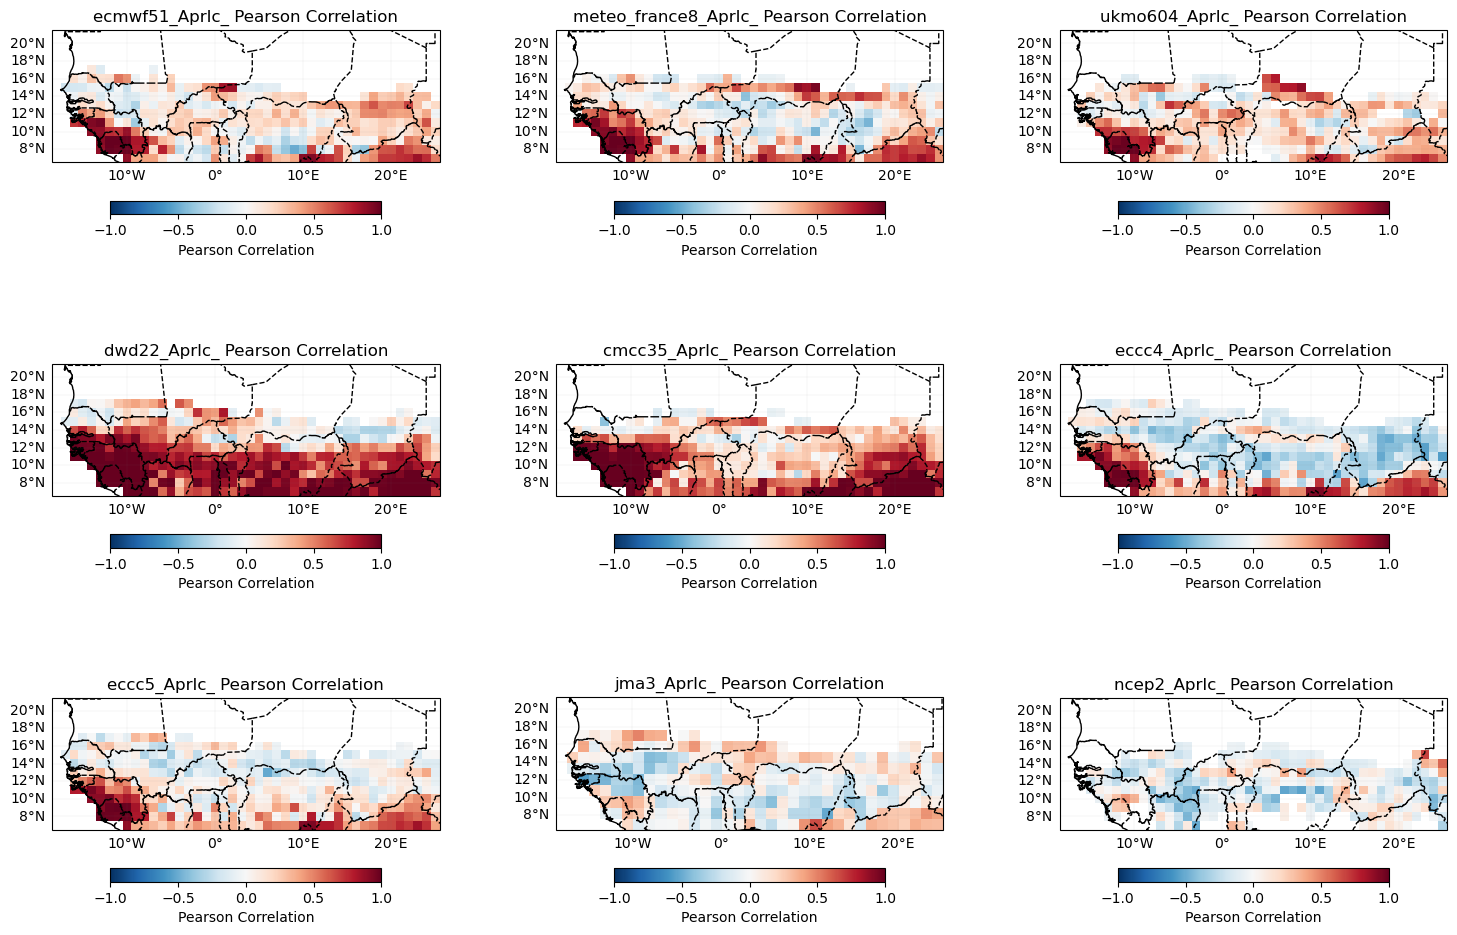

Mean Absolute Error


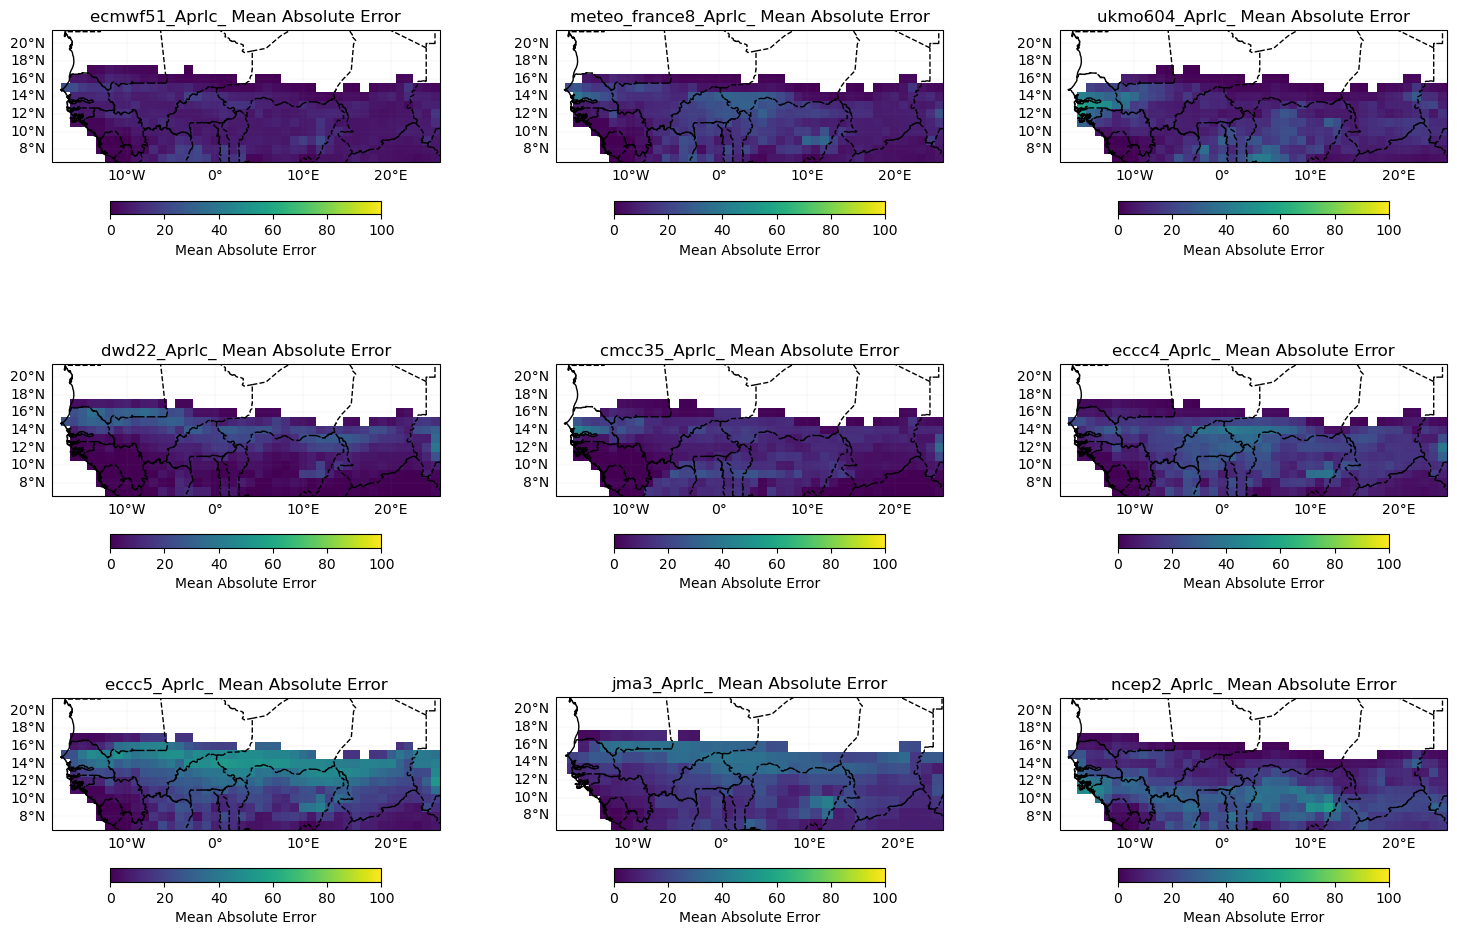

Generalized Discrimination Score


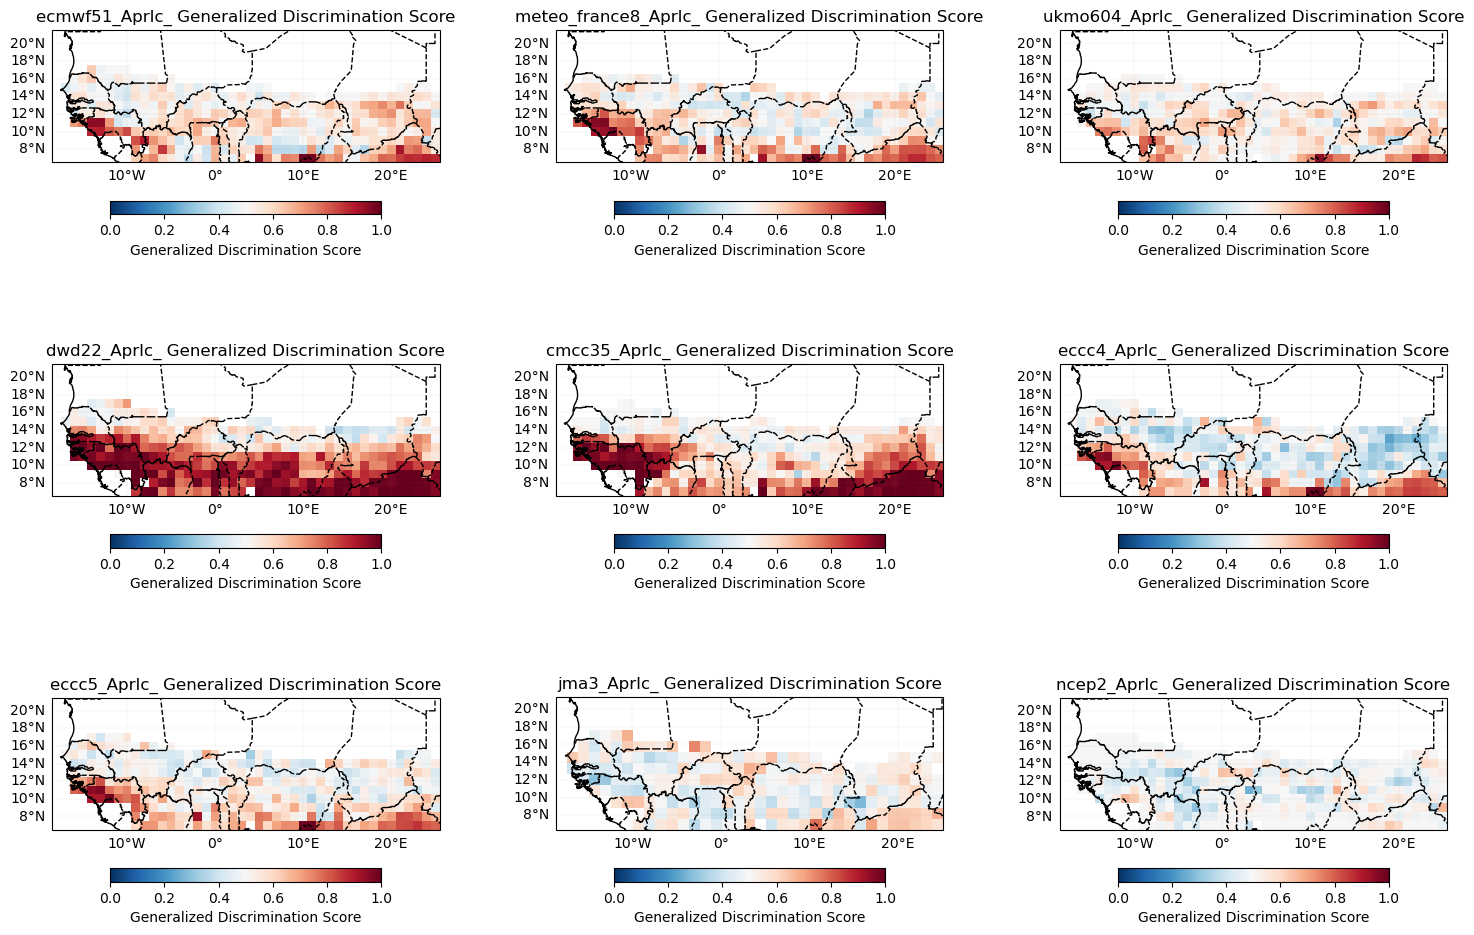

In [27]:
score = score.append('GROC') if 'GROC' not in score else score
os.makedirs(dir_save_score, exist_ok=True)
scores = {}
for i in score:
    scores[i] = was_verify.gcm_validation_compute(hindcast_files, cessation, i, month_of_initialization, clim_year_start, clim_year_end, dir_save_score, lead_time = None, ensemble_mean=None, gridded=True)
    print(was_verify.scores[i][0])
    was_verify.plot_models_score(scores[i], i, dir_save_score)

## Choice of best GCM models

In [28]:
best_models = get_best_models(center_variable, scores, metric='GROC', threshold=0.5, top_n=3, agroparam=True, gcm=False)
best_models

['DWD_22.PRCP', 'CMCC_35.PRCP', 'ECMWF_51.PRCP']

## MME for best GCM models

In [29]:
n_estimators=10
learning_rate=0.1
max_depth=5
random_state=42
dist_method=dist_method

In [ ]:
model = WAS_mme_StackXGboost_Ml(n_estimators=n_estimators,
                    learning_rate=learning_rate,
                    max_depth=max_depth,
                    random_state=random_state,
                    dist_method=dist_method)

#### Cross-validation

In [31]:
all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(cessation.sel(T=slice(str(year_start_model),str(year_end_model))), hdcsted=hindcast_files, fcsted=forecast_files, scores= scores, gcm=False, agroparam=True, ELM_ELR=False, best_models=best_models)

In [32]:
was_mme_gcm = WAS_Cross_Validator(n_splits=len(cessation.sel(T=slice(str(year_start_model),str(year_end_model))).get_index("T")), nb_omit=2)

In [33]:
hindcast_det_gcm, hindcast_prob_gcm, = was_mme_gcm.cross_validate(model, obs, all_model_hdcst, clim_year_start, clim_year_end)
hdcst_consolidated['first.approach'] = hindcast_det_gcm

Cross-validation ongoing


100%|███████████████████████████████████████████| 24/24 [10:31<00:00, 26.31s/it]


#### Verification

In [34]:
score = ['Pearson','MAE']
model_name = "MME_best_GCM_Models"

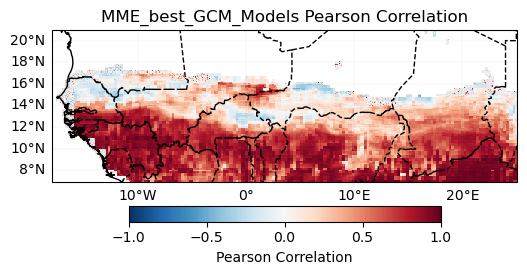

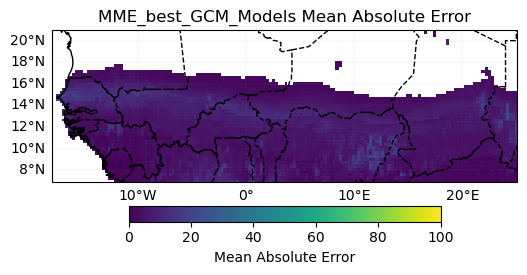

In [35]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        cessation.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_det_gcm
    )
    scores_consolidated[i] = {'first.approach': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

##### Probabilistic

In [36]:
score = ['GROC']

Generalized Discrimination Score


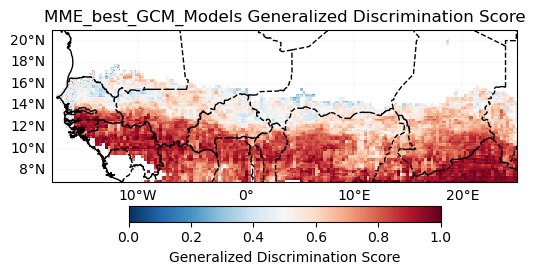

In [37]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        cessation.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_prob_gcm,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i] = {'first.approach': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

#### Forecast 

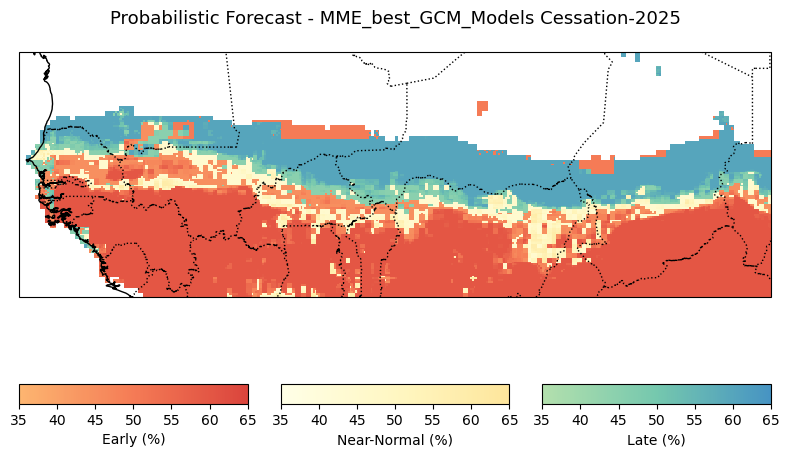

101822

In [38]:
forecast_det_gcm, forecast_prob_gcm= model.forecast(obs, clim_year_start, clim_year_end, all_model_hdcst, hindcast_det_gcm, all_model_fcst)
fcst_consolidated['first.approach'] = forecast_det_gcm
plot_prob_forecasts(dir_to_forecast, forecast_prob_gcm.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=False, labels=fcst_labels)
gc.collect()

# 2nd - Approach: Statistico-Dynamical

In [39]:
# Filter model names to identify precipitation-related models
center_variable = ['ECMWF_51.HUSS_1000', 'METEOFRANCE_8.HUSS_1000',
                   #'UKMO_603.PRCP', # Comment this line if your initialization month starts with March
                   'UKMO_604.HUSS_1000',  # Comment this line if your initialization month starts before April
                   # 'DWD_21.PRCP', # Comment this line if your initialization month starts with March
                   'DWD_22.HUSS_1000', # Comment this line if your initialization month starts before March
                   'CMCC_35.HUSS_1000', 'ECCC_4.HUSS_1000', 
                   'ECCC_5.HUSS_1000']#, 'JMA_3.HUSS_1000', 'NCEP_2.HUSS_1000'] 



# center_variable = [key for key in downloader.ModelsName().keys() if "VGRD_850" in key]



# Specify the directory to save downloaded model data
dir_to_save_model = f"{dir_s2s}/model_data"

# Define the month for model initialization (June)
month_of_initialization = "04"

# Define lead times corresponding to seasonal forecast targets (JAS season in this case)
lead_time = ["04", "05", "06"]  # July-August-September forecast period

# Define the hindcast period for model data (years 1993 to 2016)
year_start_model = 1993
year_end_model = 2016

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent = [30, -30, -20, 30] #[60, -180, -60, 180]  # [Northern, Western, Southern and Eastern] 

# Define if you want to download forecast or hindcast
forecast = None

# Define if you want all members of ensemble or doing an ensemble mean
ensemble_mean = "mean"

# Specify whether to overwrite existing files when downloading data
force_download = False

In [40]:
hindcast_files = downloader.WAS_Download_Models(
    dir_to_save_model,
    center_variable,
    month_of_initialization,
    lead_time,
    year_start_model,
    year_end_model,
    extent, 
    forecast,
    ensemble_mean,
    force_download)

Agro_PRESASS_2025/model_data/hindcast_ecmwf51_HUSS_1000_AprIc_AugSepOct_04.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/hindcast_meteofrance8_HUSS_1000_AprIc_AugSepOct_04.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/hindcast_ukmo604_HUSS_1000_AprIc_AugSepOct_04.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/hindcast_dwd22_HUSS_1000_AprIc_AugSepOct_04.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/hindcast_cmcc35_HUSS_1000_AprIc_AugSepOct_04.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/hindcast_eccc4_HUSS_1000_AprIc_AugSepOct_04.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/hindcast_eccc5_HUSS_1000_AprIc_AugSepOct_04.nc already exists. Skipping download.


In [41]:
forecast = 2025

In [42]:
forecast_files = downloader.WAS_Download_Models(
    dir_to_save_model,
    center_variable,
    month_of_initialization,
    lead_time,
    year_start_model,
    year_end_model,
    extent, 
    forecast,
    ensemble_mean,
    force_download)

Agro_PRESASS_2025/model_data/forecast_ecmwf51_HUSS_1000_AprIc_AugSepOct_04.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/forecast_meteofrance8_HUSS_1000_AprIc_AugSepOct_04.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/forecast_ukmo604_HUSS_1000_AprIc_AugSepOct_04.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/forecast_dwd22_HUSS_1000_AprIc_AugSepOct_04.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/forecast_cmcc35_HUSS_1000_AprIc_AugSepOct_04.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/forecast_eccc4_HUSS_1000_AprIc_AugSepOct_04.nc already exists. Skipping download.
Agro_PRESASS_2025/model_data/forecast_eccc5_HUSS_1000_AprIc_AugSepOct_04.nc already exists. Skipping download.


### Initialize the WAS_CCA class (default)

In [43]:
n_modes = 4
# define zone as dict : {'zone_name_key': ('Explicit_Zone_name', lon_min, lon_max, lat_min, lat_max)} 
defined_zone = {'A': ('A', -30, 30, -20, 30)} 

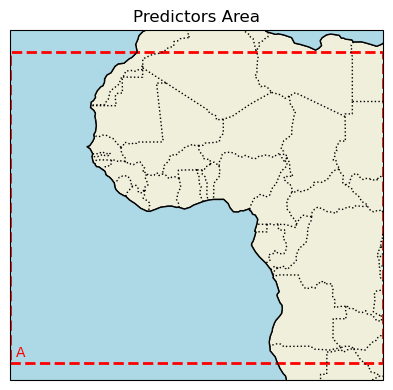

In [44]:
plot_map([extent[1],extent[3],extent[2],extent[0]], sst_indices = defined_zone, title="Predictors Area",fig_size=(6,4))

##### Modes of CCA for each model

In [45]:
was_cca = WAS_CCA(n_modes=n_modes, n_pca_modes=10, dist_method=dist_method)
was_cv = WAS_Cross_Validator(n_splits=len(cessation.sel(T=slice(str(year_start_model),str(year_end_model))).get_index("T")), nb_omit=2)

CCA Modes for model ECMWF_51.HUSS_1000


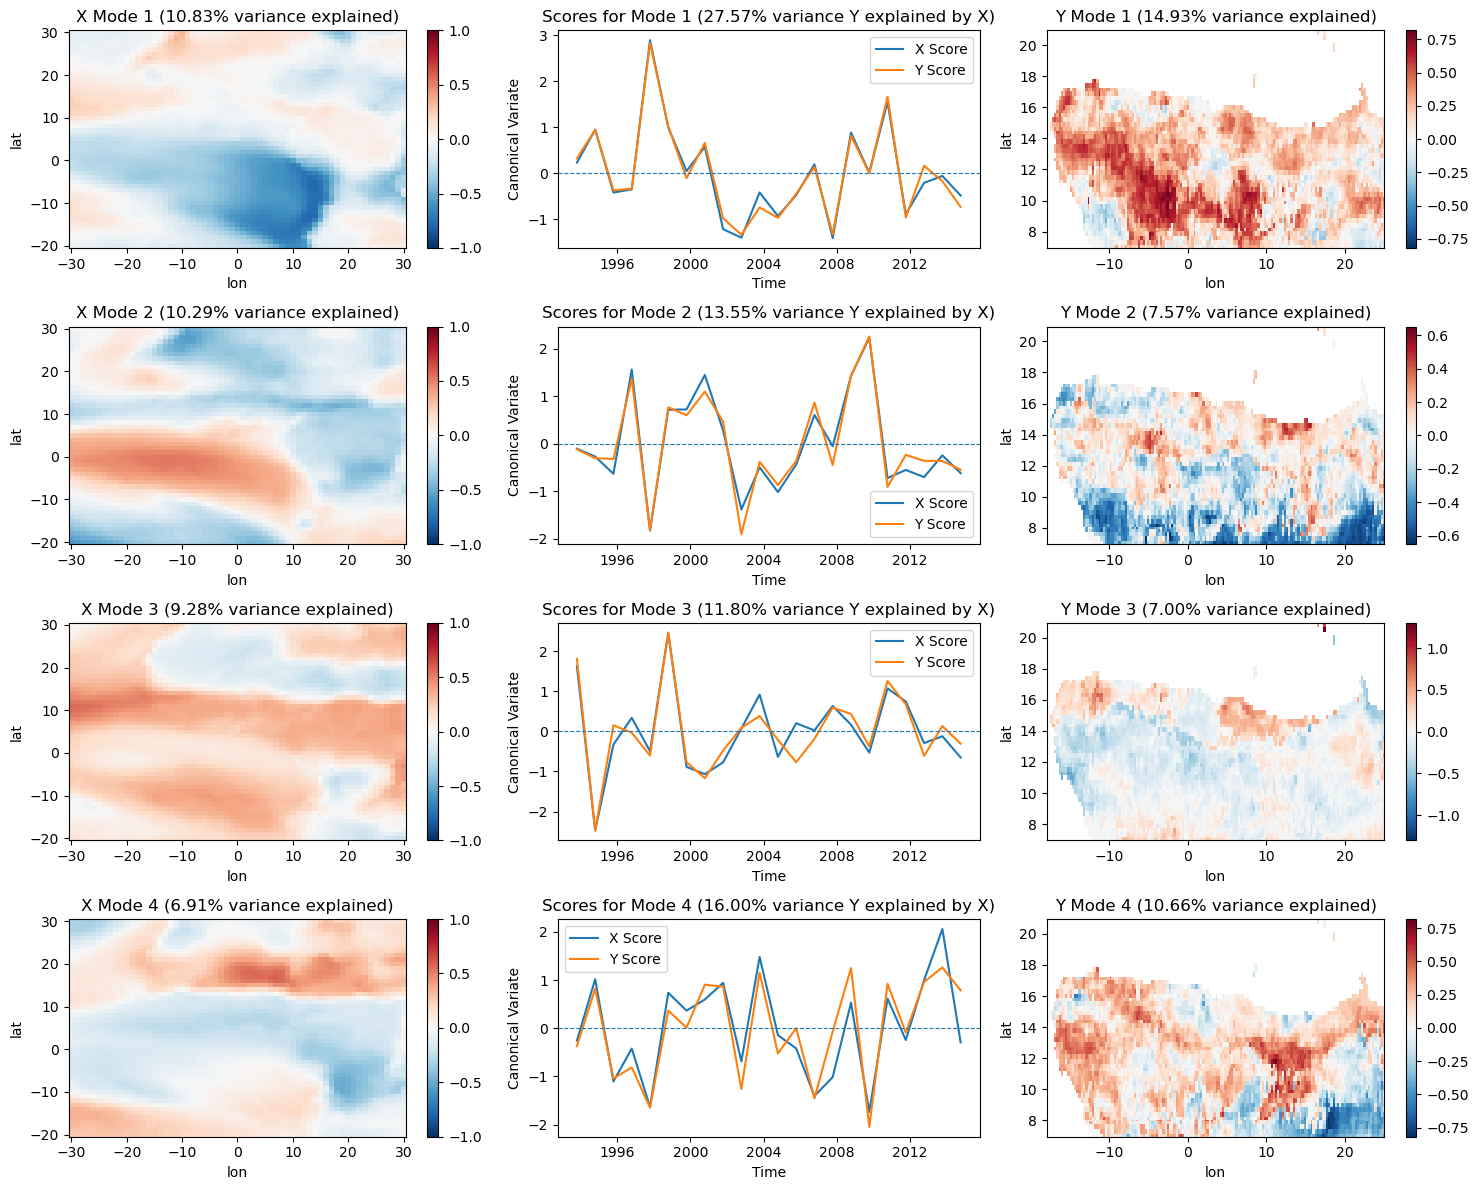

CCA Modes for model METEOFRANCE_8.HUSS_1000


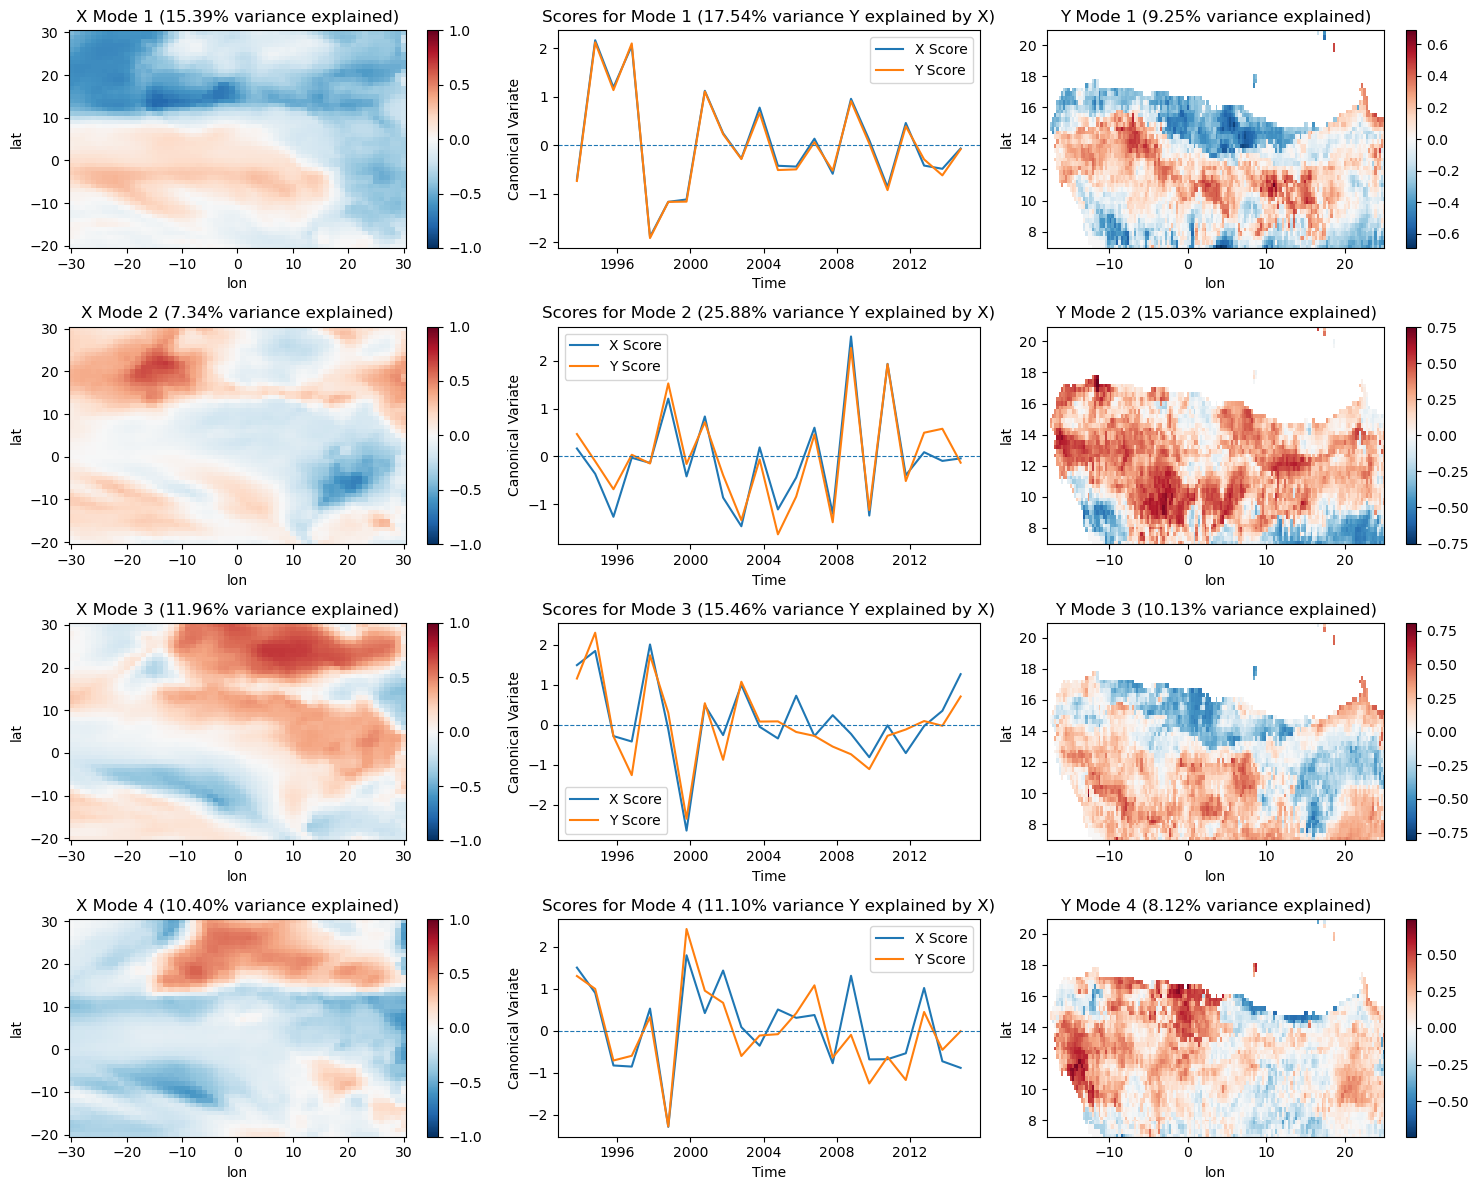

CCA Modes for model UKMO_604.HUSS_1000


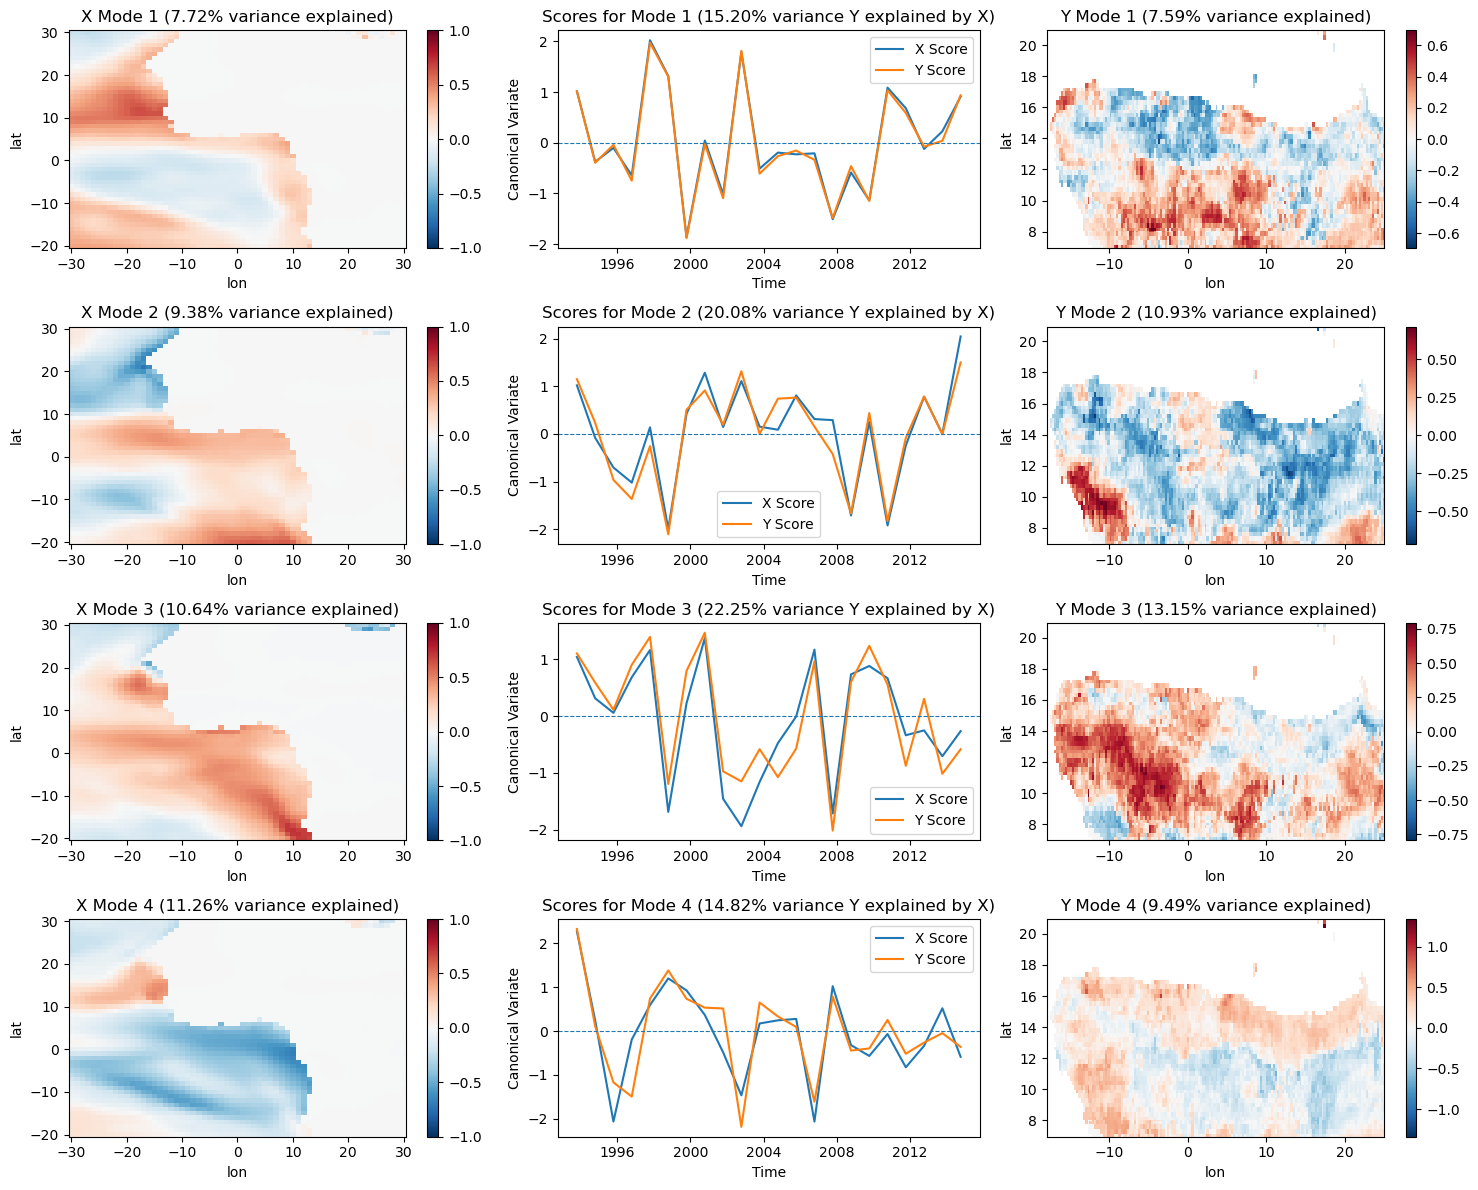

CCA Modes for model DWD_22.HUSS_1000


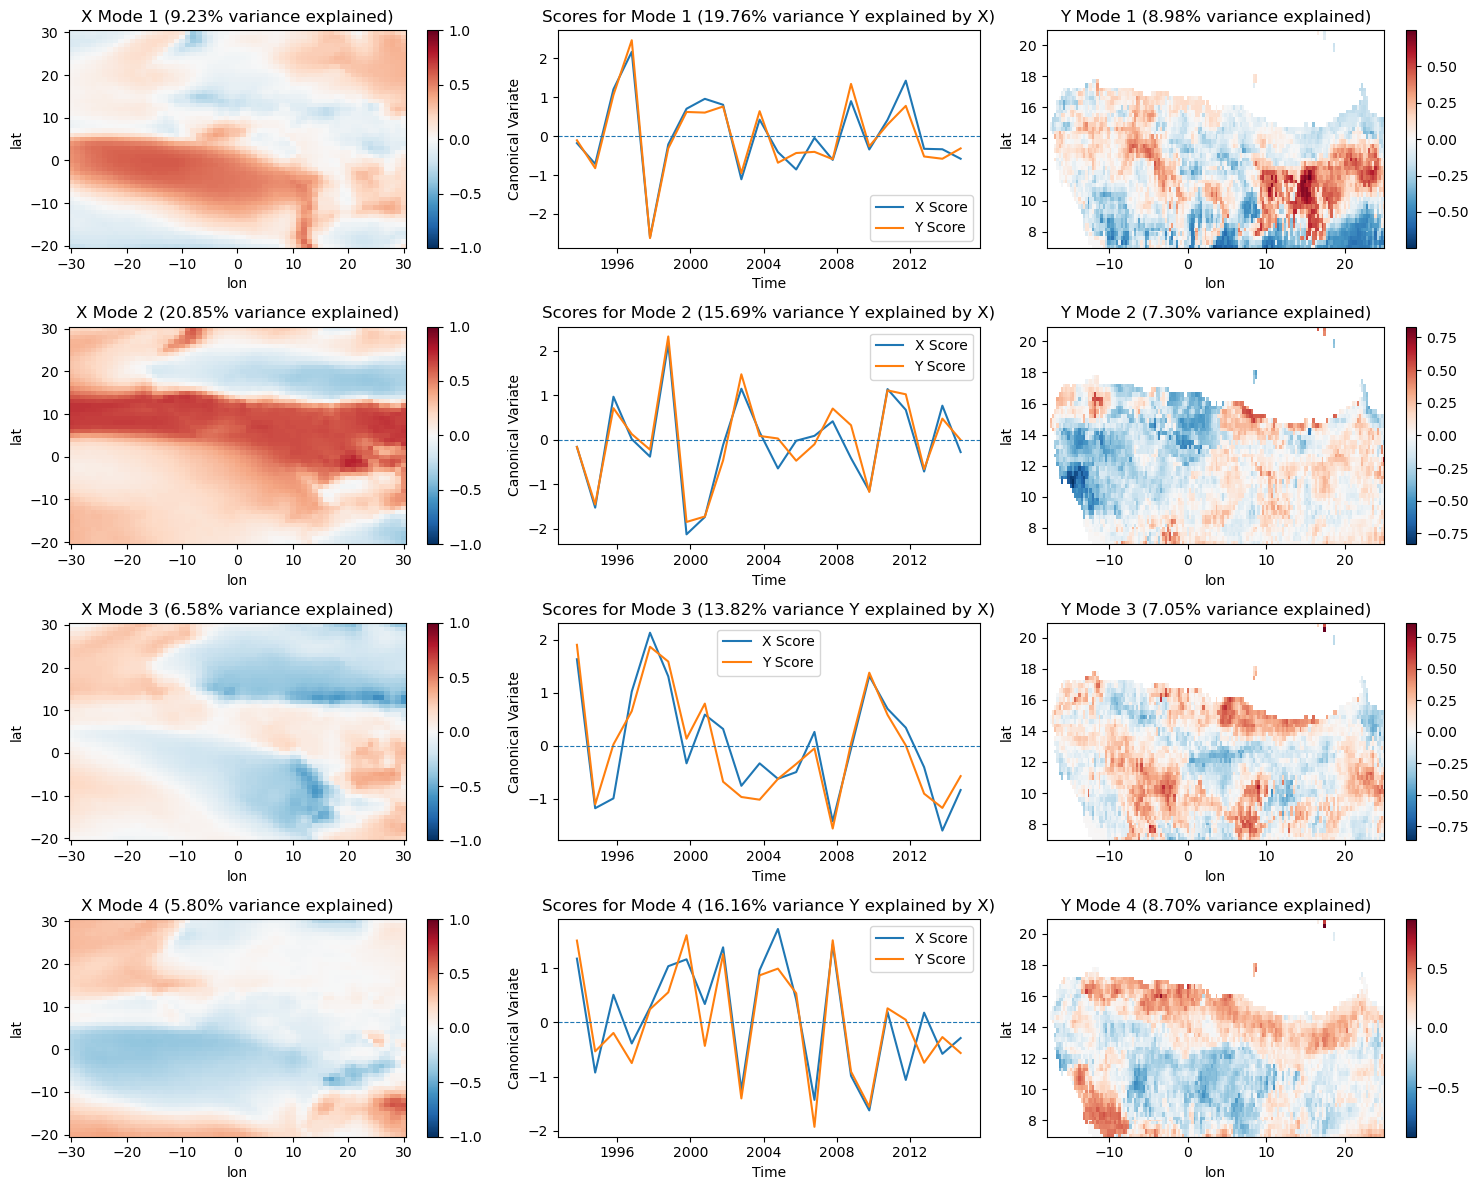

CCA Modes for model CMCC_35.HUSS_1000


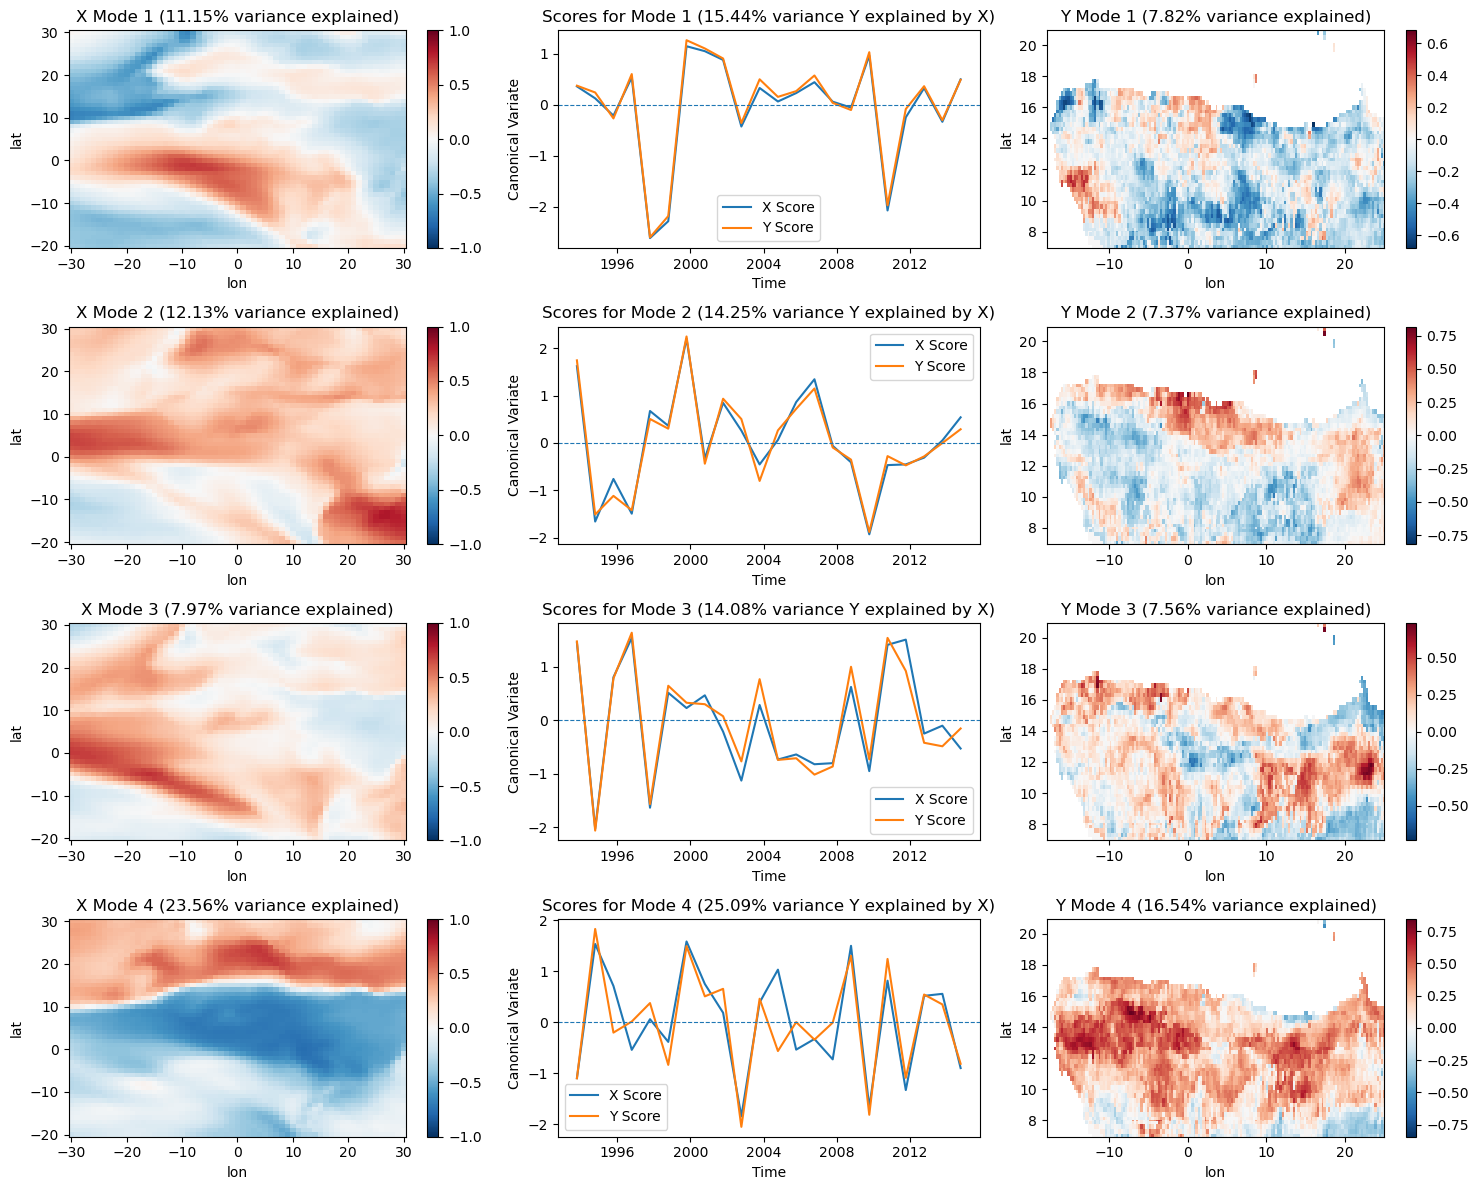

CCA Modes for model ECCC_4.HUSS_1000


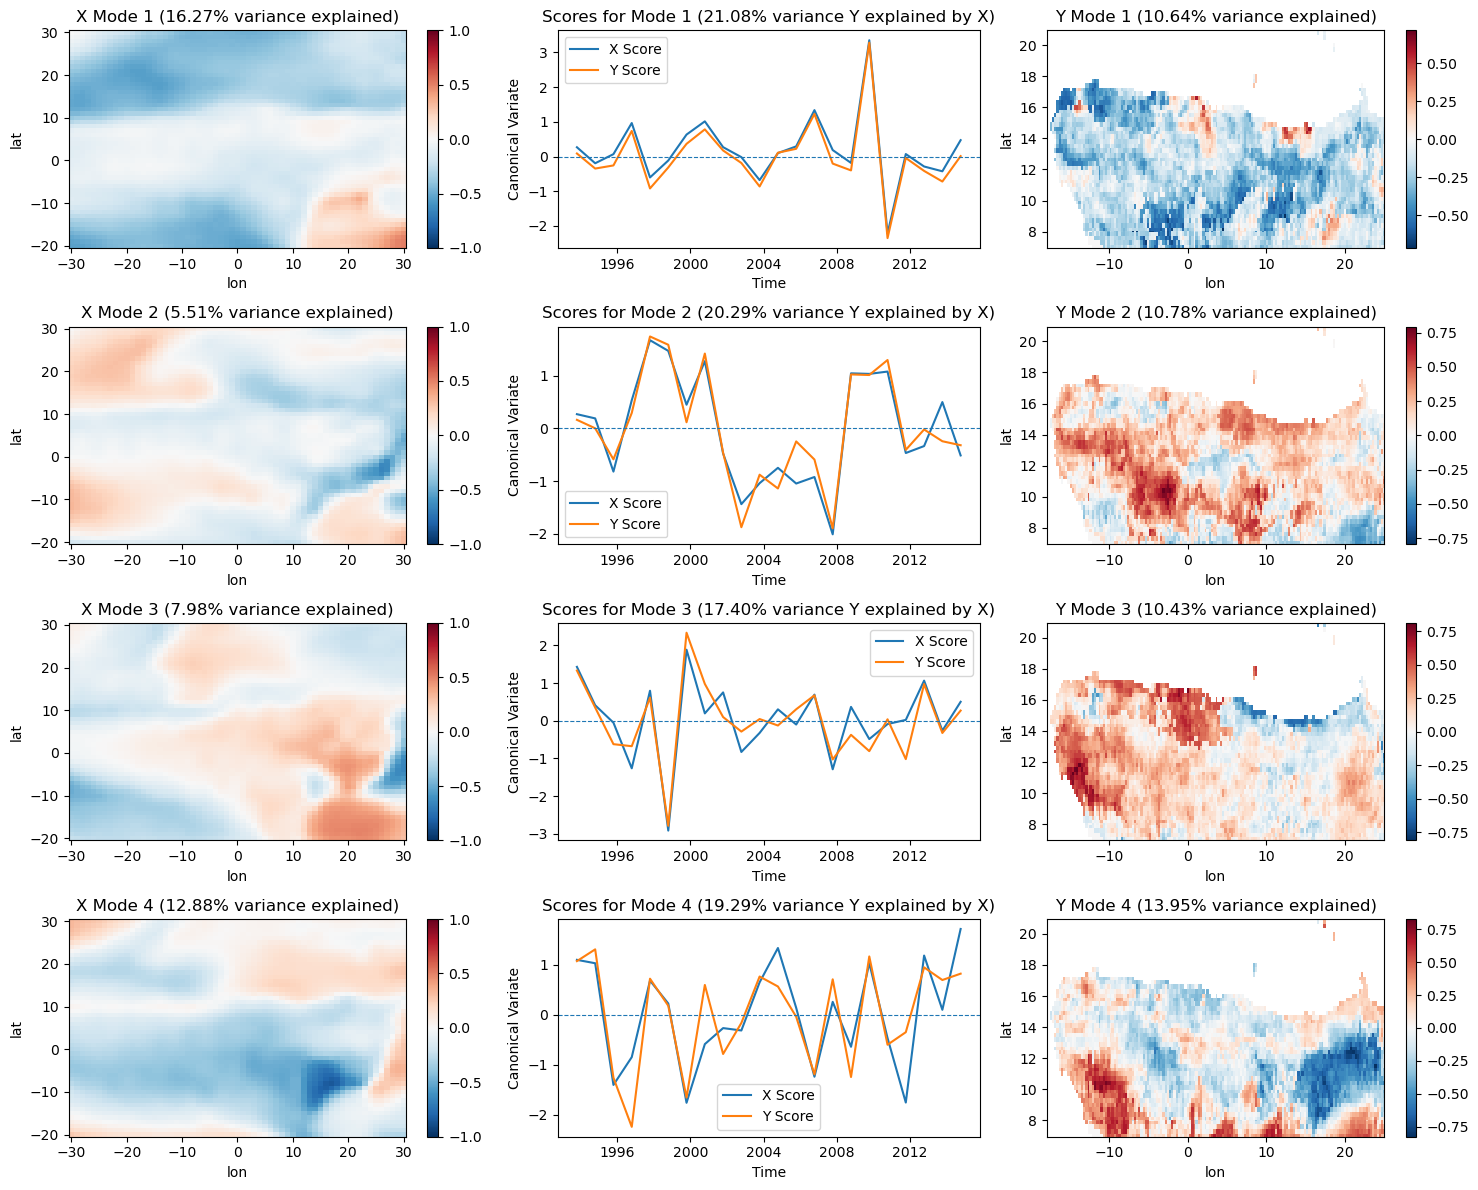

CCA Modes for model ECCC_5.HUSS_1000


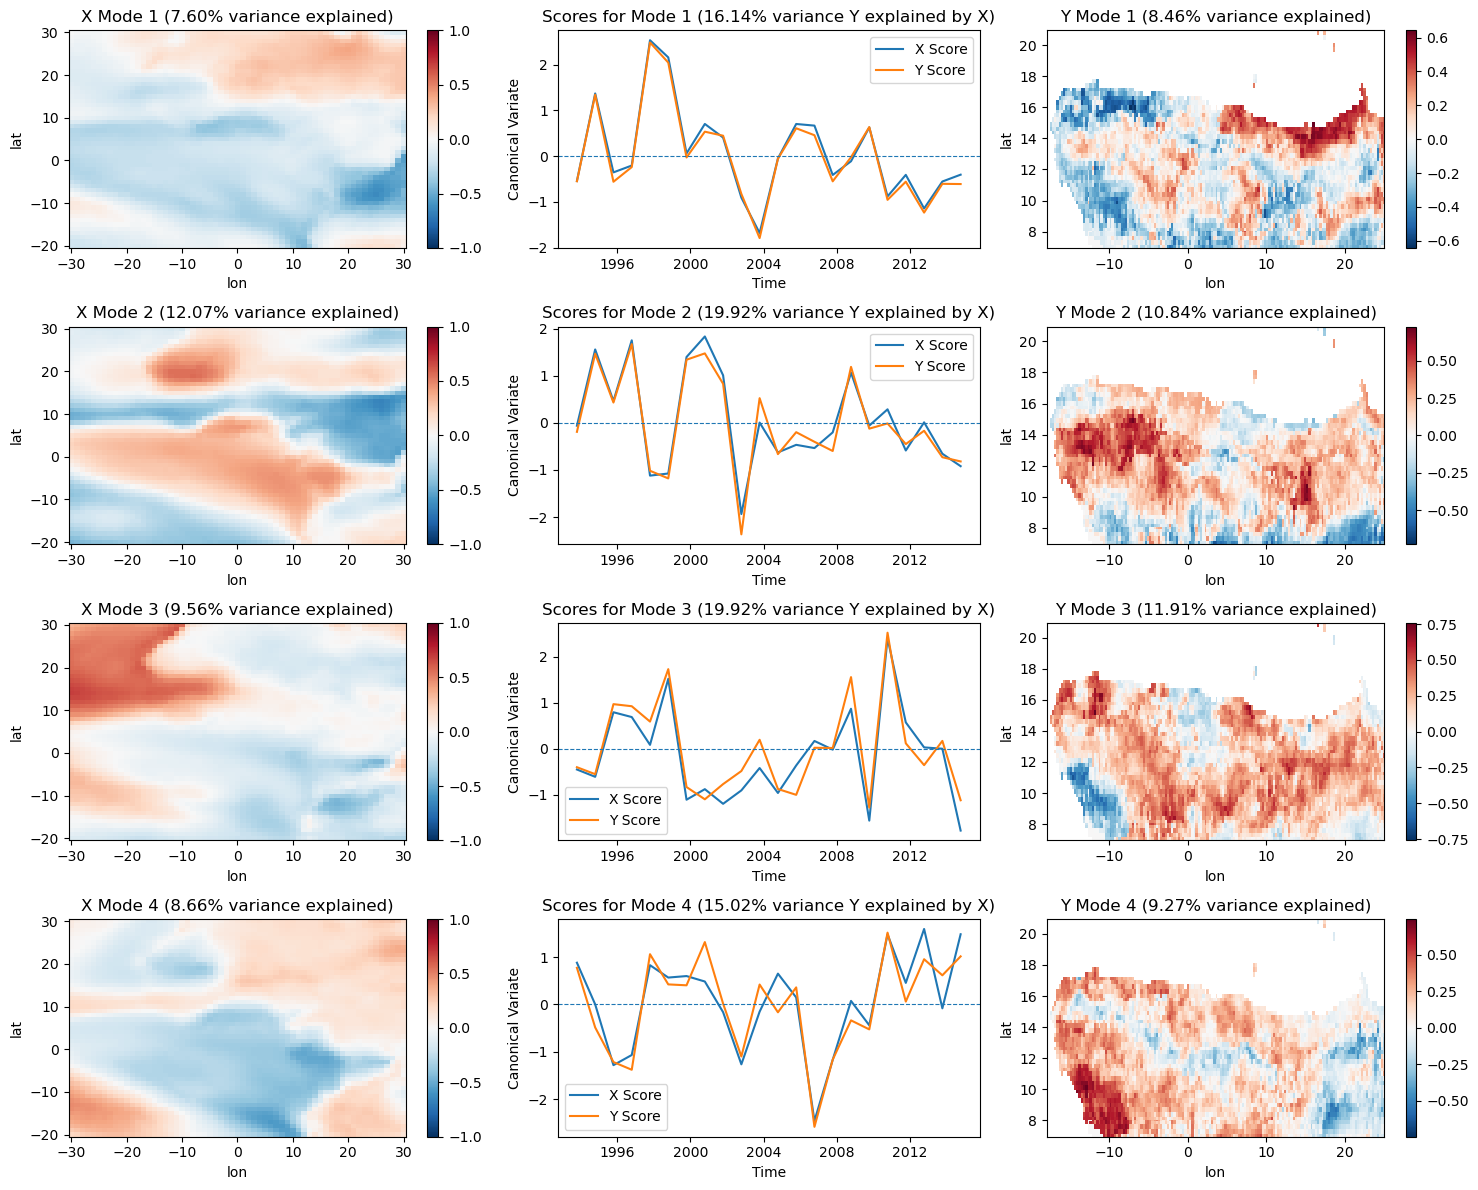

In [46]:
predictors = {}
for i in center_variable:
    predictors[i] = retrieve_single_zone_for_PCR(dir_to_save_model, defined_zone, i, year_start_model, year_end_model, clim_year_start=clim_year_start, clim_year_end=clim_year_end, model=True, month_of_initialization=month_of_initialization, lead_time=lead_time)
    predictor = predictors[i].isel(T = slice(None,-1))
    predictor['T'] = cessation.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(f"CCA Modes for model {i}")
    was_cca.plot_cca_results(X=predictor, Y=cessation.sel(T=slice(str(year_start_model),str(year_end_model))) , clim_year_start=clim_year_start, clim_year_end=clim_year_end)

#### Cross validation

In [47]:
hindcast_det_dynam_all = {}
hindcast_prob_dynam_all = {}
for key, predictor in predictors.items():
    predictor = predictor.isel(T = slice(None,-1))
    predictor['T'] = cessation.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(key.split(".")[0])
    hindcast_det_dynam_all[key], hindcast_prob_dynam_all[key] = was_cv.cross_validate(was_cca, cessation.sel(T=slice(str(year_start_model),str(year_end_model))).sel(T=slice(str(year_start_model),str(year_end_model))), predictor, clim_year_start, clim_year_end)

ECMWF_51
Cross-validation ongoing


100%|███████████████████████████████████████████| 24/24 [00:28<00:00,  1.20s/it]


METEOFRANCE_8
Cross-validation ongoing


100%|███████████████████████████████████████████| 24/24 [00:28<00:00,  1.19s/it]


UKMO_604
Cross-validation ongoing


...

100%|███████████████████████████████████████████| 24/24 [00:29<00:00,  1.22s/it]


ECCC_4
Cross-validation ongoing


100%|███████████████████████████████████████████| 24/24 [00:29<00:00,  1.24s/it]


ECCC_5
Cross-validation ongoing


100%|███████████████████████████████████████████| 24/24 [00:29<00:00,  1.22s/it]


#### Verification (individual)

###### Deterministic

In [48]:
score = ['Pearson','MAE']
model_name = "CCA_2nd_Approch"

Pearson Correlation


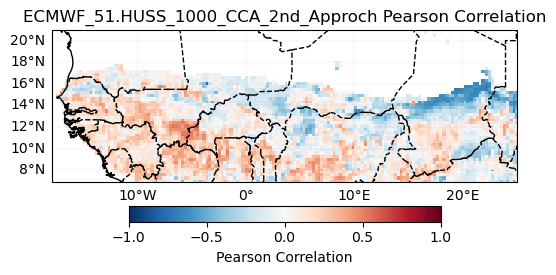

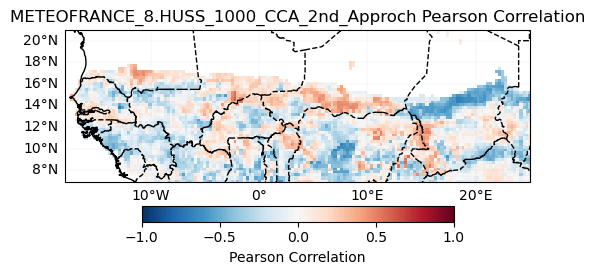

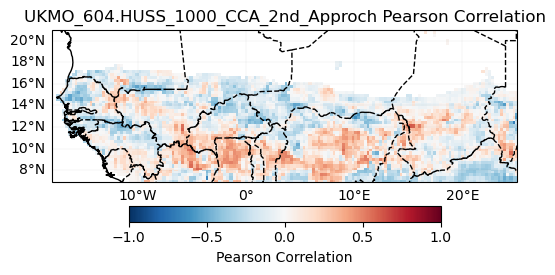

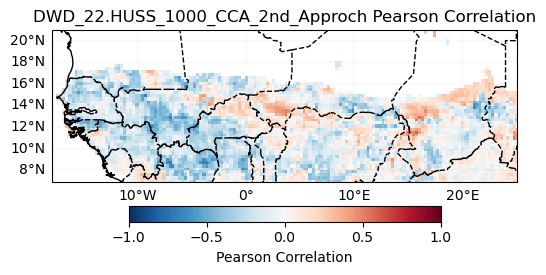

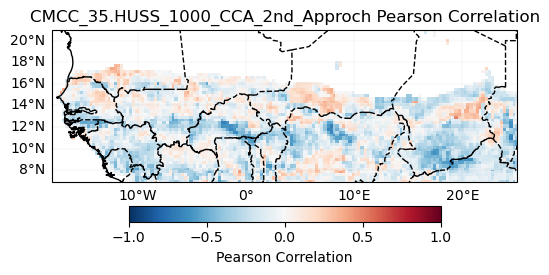

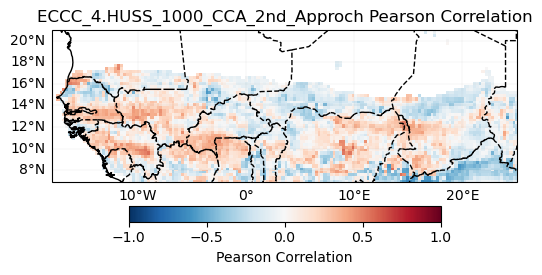

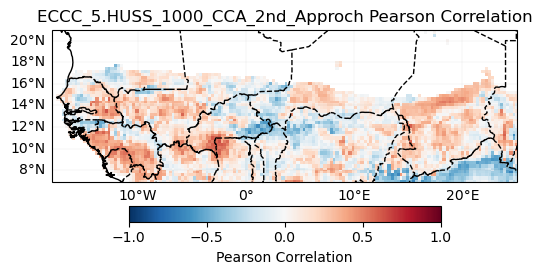

Mean Absolute Error


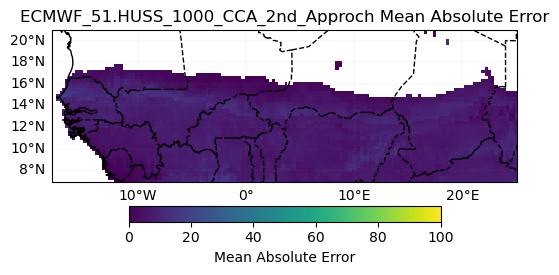

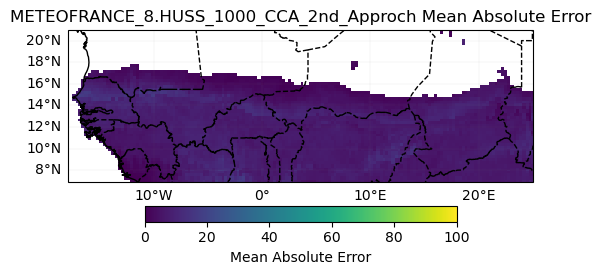

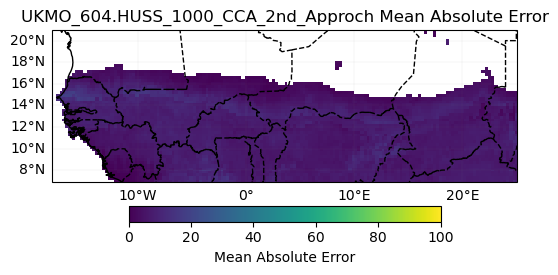

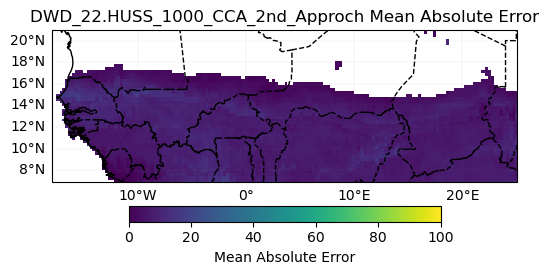

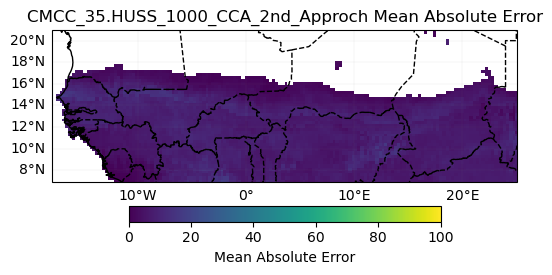

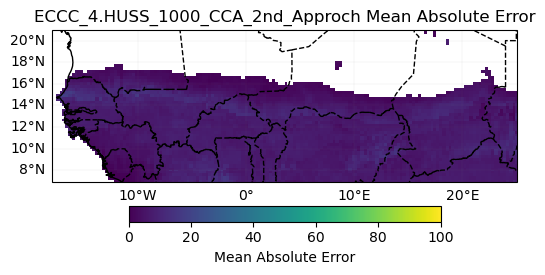

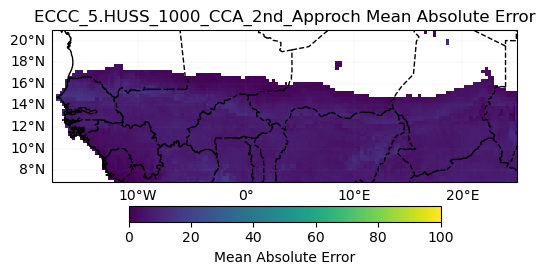

In [49]:
cca_scores = {}
tmp = {}
for i in score:
    print(was_verify.scores[i][0])
    for key, hdcst in hindcast_det_dynam_all.items():
        tmp[key] = was_verify.compute_deterministic_score(
            was_verify.get_scores_metadata()[i][5],
            cessation.sel(T=slice(str(year_start_model),str(year_end_model))),
            hindcast_det_dynam_all[key]
        )
        was_verify.plot_model_score(tmp[key], i, dir_save_score, f"{key}_{model_name}")
    cca_scores[i] = tmp

###### Probabilistic

In [50]:
score = ['GROC']

Generalized Discrimination Score


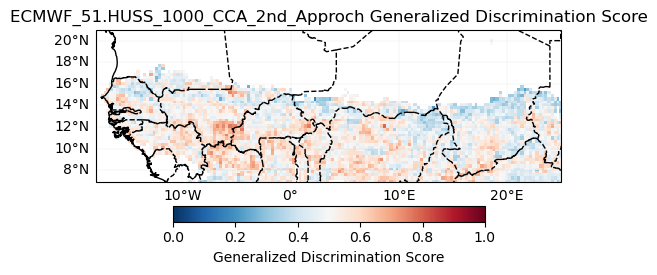

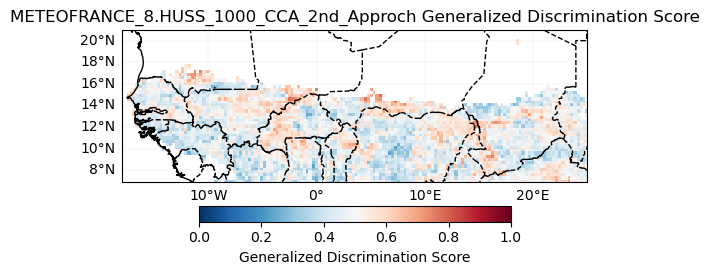

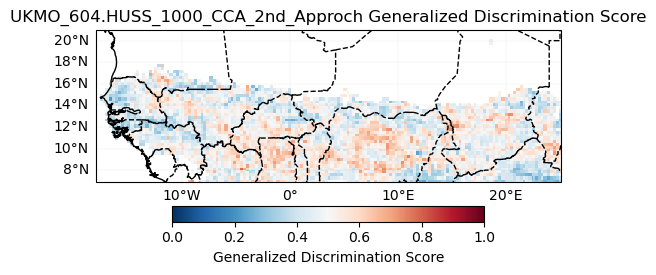

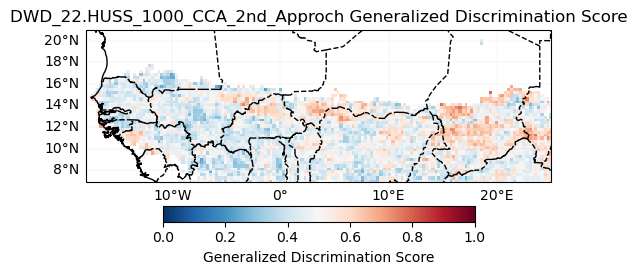

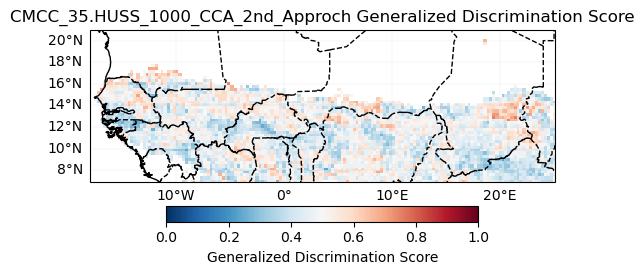

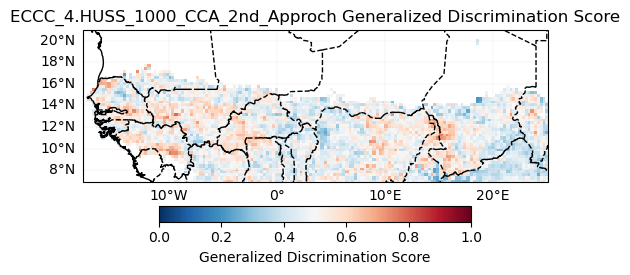

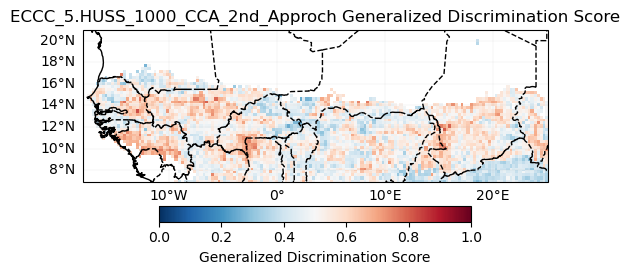

In [51]:
score = score.append('GROC') if 'GROC' not in score else score
tmp = {}
for i in score:
    print(was_verify.scores[i][0])
    for key, hdcst in hindcast_det_dynam_all.items():
        tmp[key] = was_verify.compute_probabilistic_score(
            was_verify.get_scores_metadata()[i][5],
            cessation.sel(T=slice(str(year_start_model),str(year_end_model))),
            hindcast_prob_dynam_all[key],
            clim_year_start,
            clim_year_end)
        was_verify.plot_model_score(tmp[key], i, dir_save_score, f"{key}_{model_name}")
    cca_scores[i] = tmp

#### Forecast (individual)

ECMWF_51


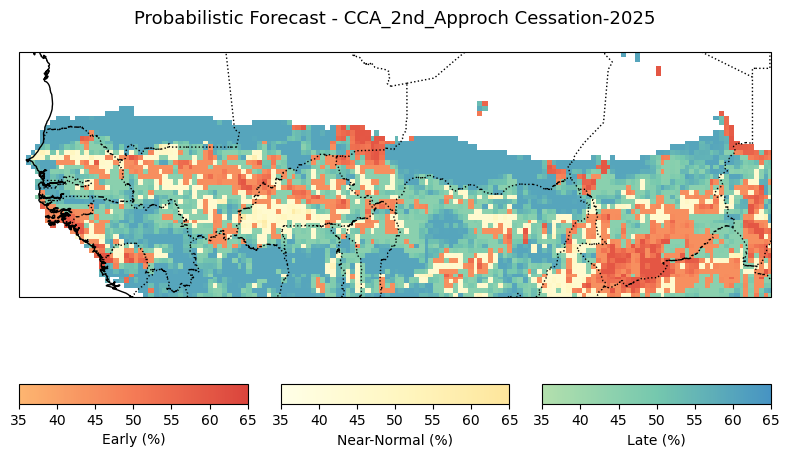

METEOFRANCE_8


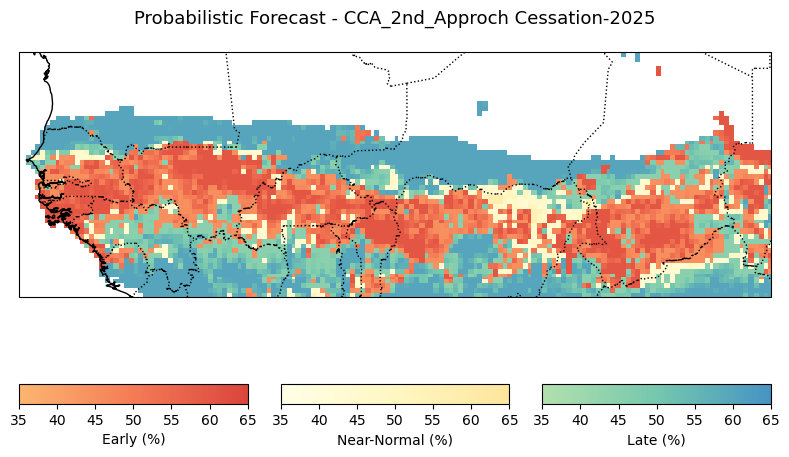

UKMO_604


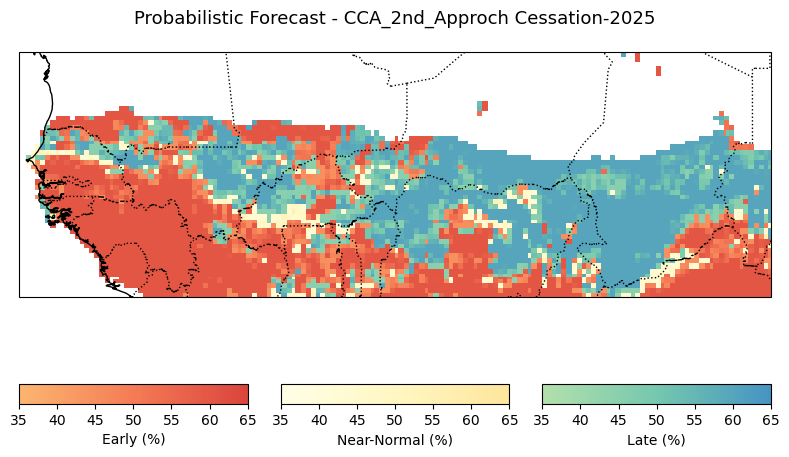

DWD_22


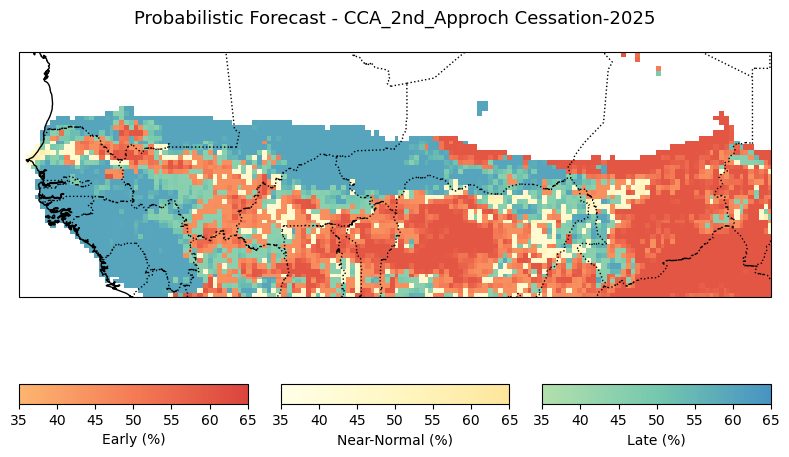

CMCC_35


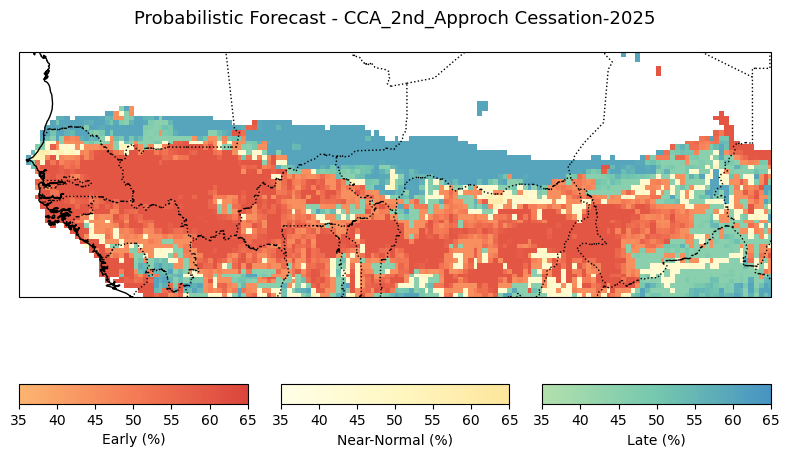

ECCC_4


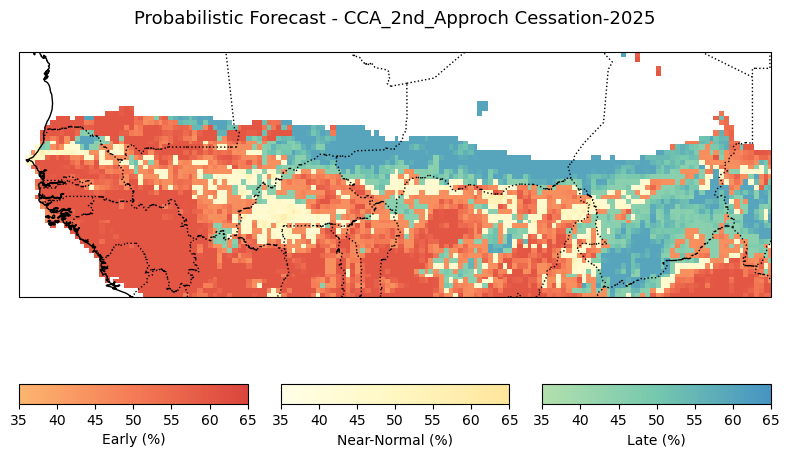

ECCC_5


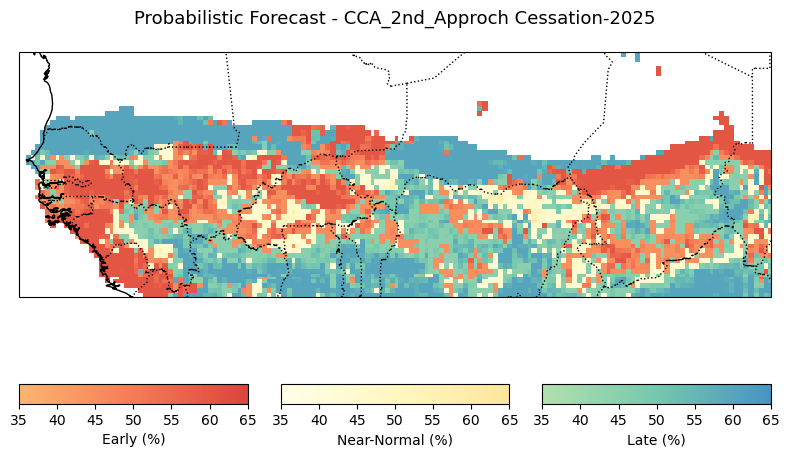

In [52]:
forecast_det_dynam_all = {}
forecast_prob_dynam_all = {}
for key, predictor in predictors.items():
    predictor_f = predictor.isel(T=[-1])
    predictor = predictor.isel(T = slice(None,-1))
    predictor['T'] = cessation.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(key.split(".")[0])
    forecast_det_dynam_all[key], forecast_prob_dynam_all[key] = was_cca.forecast(cessation.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, predictor, hindcast_det_dynam_all[key], predictor_f)
    plot_prob_forecasts(dir_to_forecast, forecast_prob_dynam_all[key].drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=False, labels=fcst_labels)

### MME 2nd-Approach: Statistico-Dynamical

In [120]:
#### Select some models
best_models = get_best_models(center_variable, cca_scores, metric='Pearson', threshold=0.2, top_n=5, gcm=False)
best_models

['ECMWF_51.HUSS_1000',
 'ECCC_5.HUSS_1000',
 'DWD_22.HUSS_1000',
 'METEOFRANCE_8.HUSS_1000',
 'UKMO_604.HUSS_1000']

In [131]:
was_2nd_mme = WAS_mme_Weighted(equal_weighted=False, dist_method=dist_method, metric="Pearson", threshold=0.5)

In [132]:
all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(cessation.sel(T=slice(str(year_start_model),str(year_end_model))),hdcsted=hindcast_det_dynam_all, fcsted=forecast_det_dynam_all, gcm=False, ELM_ELR=False,  best_models=best_models, scores=cca_scores, model=False)
hindcast_det_mme_2nd, forecast_det_mme_2nd  = was_2nd_mme.compute(obs, all_model_hdcst, all_model_fcst, best_score, complete=True)
hindcast_prob_mme_2nd = was_2nd_mme.compute_prob(cessation.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, hindcast_det_mme_2nd)
hdcst_consolidated['snd.approach'] = hindcast_det_mme_2nd

#### Verification

###### Deterministic

In [133]:
score = ['Pearson','MAE']
model_name = "MME_2nd_Approach"

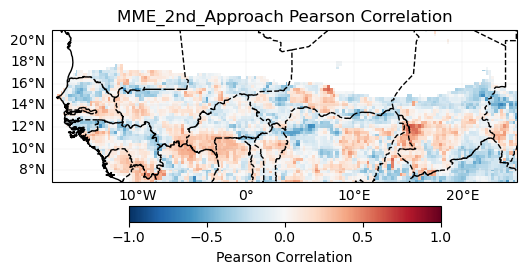

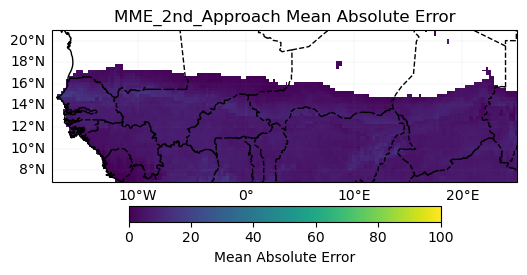

In [135]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        cessation.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_det_mme_2nd
    )
    scores_consolidated[i]['snd.approach'] = r
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

###### Probabilistic

In [129]:
score = ['GROC']

Generalized Discrimination Score


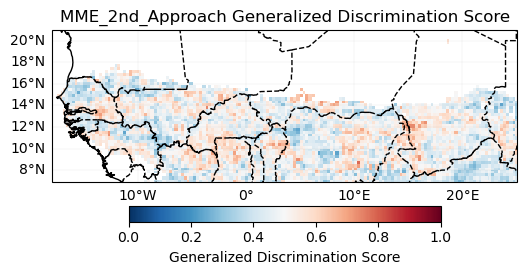

In [130]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        cessation.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_prob_mme_2nd,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i]['snd.approach'] = r
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

#### Forecast 

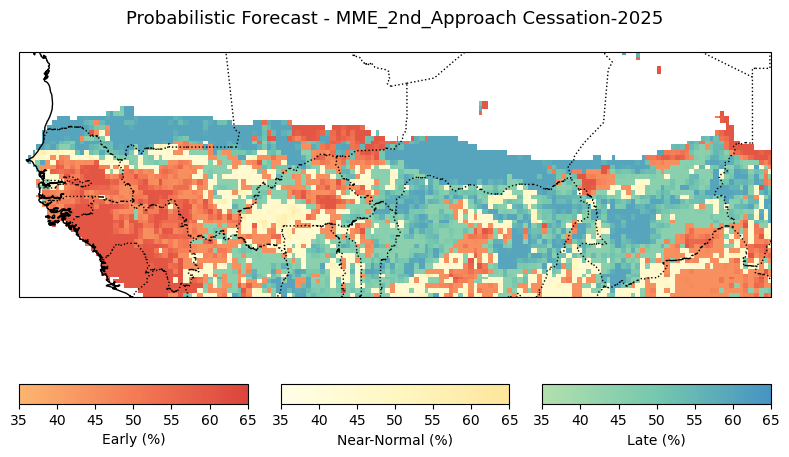

In [60]:
forecast_prob_mme_2nd = was_2nd_mme.forecast(cessation.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, hindcast_det_mme_2nd, forecast_det_mme_2nd)
fcst_consolidated['snd.approach'] = forecast_det_mme_2nd
plot_prob_forecasts(dir_to_forecast, forecast_prob_mme_2nd.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=False, labels=fcst_labels)

# 4th - Analog-based seasonal forecast

## Initialize WAS_Analog class

In [61]:
## Load class for model, cross-validation and verification
model = WAS_Analog(f"{dir_s2s}/analog", 
                    1990, 2025,"NOAA.SST", "NCEP_2.SST",
                    method_analog ="pca_based", 
                    month_of_initialization=3,
                    clim_year_start=clim_year_start, 
                    clim_year_end=clim_year_end,
                    define_extent = [-180, 180, -60, 60],
                    dist_method=dist_method
                    )

#### Cross-validation

In [62]:
was_analog_cv = WAS_Cross_Validator(n_splits=len(cessation.get_index("T")), nb_omit=2)

In [ ]:
hindcast_analog_det, hindcast_analog_prob = was_analog_cv.cross_validate(model, cessation, clim_year_start=clim_year_start, clim_year_end=clim_year_end)
hdcst_consolidated['fourth.approach'] = hindcast_analog_det.sel(T=slice(str(year_start_model),str(year_end_model)))

#### Verification

###### Deterministic

In [64]:
score = ['Pearson','MAE']
model_name = "analog_method"

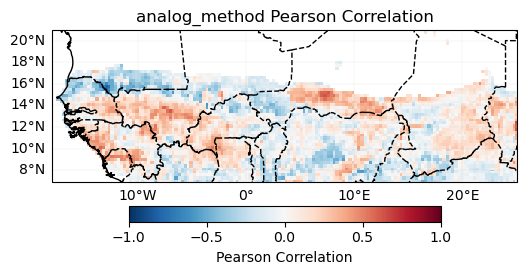

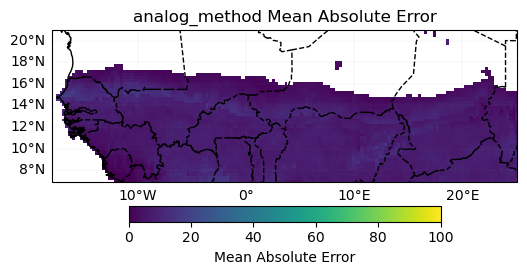

In [65]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        cessation,
        hindcast_analog_det
    )
    scores_consolidated[i]['fourth.approach'] = r
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

###### Probabilistic

In [66]:
score = ['GROC']

Generalized Discrimination Score


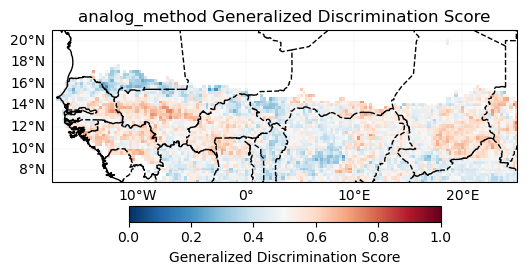

In [67]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        cessation,
        hindcast_analog_prob,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i]['fourth.approach'] = r
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

#### Forecast

Agro_PRESASS_2025/analog/NOAA_SST_3_1990_2025_JanFebMarAprMayJunJulAugSepOctNovDec.nc already exists. Skipping download.
Lead time not provided. Using months: [1, 2, 3, 4, 5] with Mar as initialization month
Agro_PRESASS_2025/analog/forecast_ncep2_SST_MarIc_AprMayJunJulAug.nc
File 'Agro_PRESASS_2025/analog/forecast_ncep2_SST_MarIc_AprMayJunJulAug.nc' already exists. Skipping download.
All requested SST data has been processed.


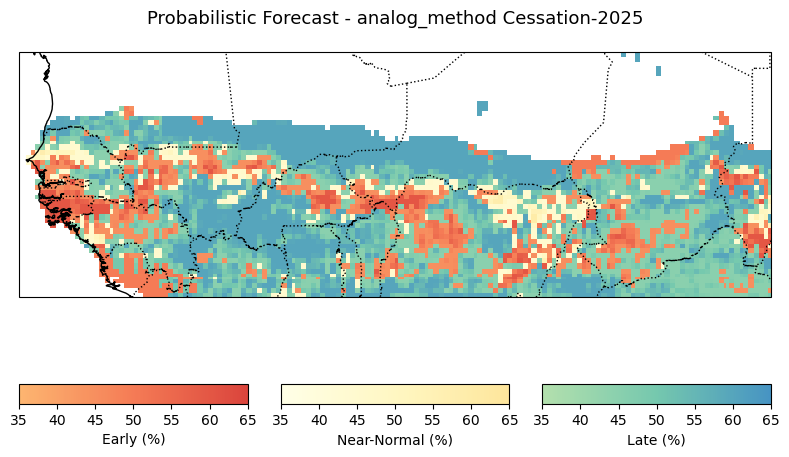

In [68]:
ddd, similar_years, forecast_det_analog, forecast_prob_analog = model.forecast(cessation, clim_year_start, clim_year_end, hindcast_analog_det, forecast)
fcst_consolidated['fourth.approach'] = forecast_det_analog
plot_prob_forecasts(dir_to_forecast, forecast_prob_analog.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=False, labels=fcst_labels)

In [ ]:
## Analysis SST evolution
model.composite_plot(cessation, clim_year_start, clim_year_end, hindcast_analog_det, plot_predictor=True)

# Consolidated Forecasts

In [136]:
best_models = ["first.approach", 'snd.approach', 'third.approach', 'fourth.approach']

#### Cross-validation

In [137]:
all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(cessation.sel(T=slice(str(year_start_model),str(year_end_model))),hdcsted=hdcst_consolidated, fcsted=fcst_consolidated, gcm=False, ELM_ELR=False,  best_models=best_models, scores=scores_consolidated, model=False)

In [ ]:
was_mme = WAS_mme_Weighted(equal_weighted=False, dist_method=dist_method, metric="Pearson", threshold=0.5)

In [138]:
hindcast_det, forecast_det  = was_mme.compute(obs, all_model_hdcst, all_model_fcst, best_score, complete=True)
hindcast_prob = was_mme.compute_prob(cessation.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, hindcast_det)

#### Consolidated forecast Skill

In [139]:
score = ['Pearson','MAE']
model_name = "Consolidated Forecasts"

###### Deterministic

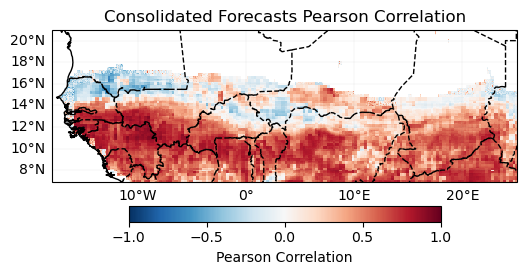

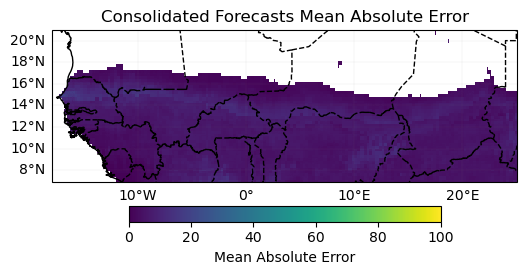

In [140]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        cessation.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_det
    )
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

##### Probabilistic

In [90]:
score = ['GROC']

Generalized Discrimination Score


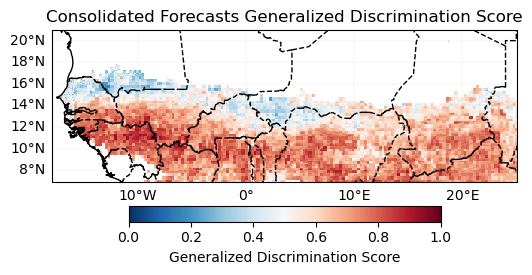

In [91]:
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        cessation.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_prob,
        clim_year_start,
        clim_year_end) 
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

### Forecast 

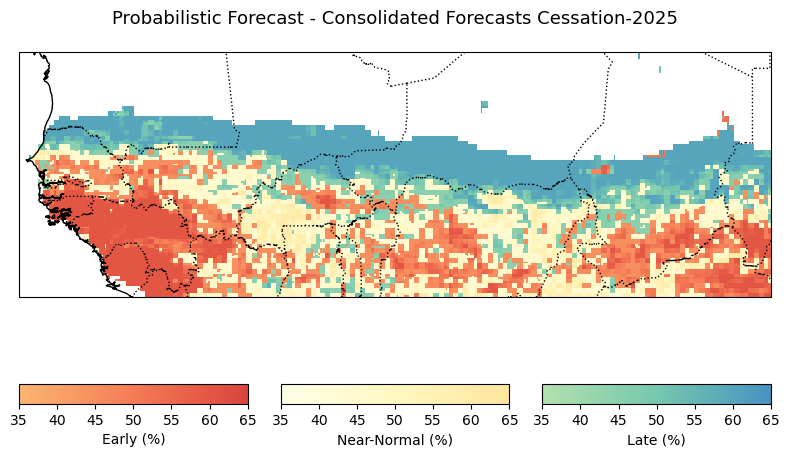

In [92]:
forecast_prob = was_mme.forecast(cessation.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, hindcast_det, forecast_det)
plot_prob_forecasts(dir_to_forecast, forecast_prob.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast}", reverse_cmap=False, labels=fcst_labels)

#### Save Forecast for future evaluation

In [78]:
forecast_det.to_netcdf(f'{dir_to_forecast}/Forecast_Det{season_str}_{forecast}.nc')

In [79]:
forecast_prob.to_netcdf(f'{dir_to_forecast}/Forecast_Prob{season_str}_{forecast}.nc')

###       ------------------------------------------------------- END --------------------------------------------------

In [141]:
!jupyter nbconvert --to html --no-input ./01_MME_Cessation.ipynb

[NbConvertApp] Converting notebook ./01_MME_Cessation.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 58 image(s).
[NbConvertApp] Writing 10097082 bytes to 01_MME_Cessation.html
